In [1]:
%pip install numpy pandas scikit-learn scipy matplotlib seaborn yfinance torch optuna gym

  Using cached torch-2.10.0-cp312-cp312-win_amd64.whl.metadata (31 kB)
  Using cached optuna-4.7.0-py3-none-any.whl.metadata (17 kB)
  Using cached gym-0.26.2.tar.gz (721 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached gym_notices-0.1.0-py3-none-any.whl.metadata (1.2 kB)
  Using cached mako-1.3.10-py3-none-any.whl.metadata (2.9 kB)
   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
   ----------------------------

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


INFO:__main__:🚀 Using device: cpu
INFO:__main__:📊 Attempting Alpha Vantage for SPY...


Note: you may need to restart the kernel to use updated packages.

🚀 INITIALIZING HEDGING PROJECT WITH ROBUST DATA PIPELINE
🚀 ADVANCED DERIVATIVE HEDGING WITH DEEP REINFORCEMENT LEARNING

📊 Step 1: Fetching Market Data...


INFO:__main__:📊 Attempting pandas-datareader for SPY...
INFO:__main__:📊 Attempting Stooq for SPY...
INFO:__main__:✅ Stooq success: 1006 days


✅ Data shape: (976, 11)
📅 Date range: 2020-02-14 00:00:00 to 2023-12-29 00:00:00
📈 Features: ['Open', 'High', 'Low', 'Close', 'Volume', 'Returns', 'Log_Returns', 'Realized_Vol', 'Volume_MA', 'Volume_Ratio', 'RSI']

⚙️ Step 2: Defining Option Contract...
✅ Strike: $327.65
✅ Initial Price: $312.05
✅ Time to Maturity: 30 days

🌍 Step 3: Creating Hedging Environment...
✅ State Dimension: 10
✅ Action Dimension: 1

🤖 Step 4: Creating PPO Agent...

🎯 Step 5: Training Agent (this may take a few minutes)...


Training:   6%|████▎                                                                   | 9/150 [00:00<00:01, 86.57it/s]INFO:__main__:Episode 20: Reward=-100.00, Hedging Error=0.5126, PnL=$-6.26
INFO:__main__:Episode 40: Reward=-100.00, Hedging Error=0.7608, PnL=$-9.29
INFO:__main__:Episode 60: Reward=-3.41, Hedging Error=0.0386, PnL=$0.45
Training:  45%|███████████████████████████████▎                                      | 67/150 [00:00<00:00, 356.05it/s]INFO:__main__:Episode 80: Reward=-5.77, Hedging Error=0.0653, PnL=$0.77
INFO:__main__:Episode 100: Reward=-52.04, Hedging Error=0.2319, PnL=$-2.83
INFO:__main__:Episode 120: Reward=-100.00, Hedging Error=0.5018, PnL=$-6.13
Training: 100%|█████████████████████████████████████████████████████████████████████| 150/150 [00:00<00:00, 432.48it/s]


✅ Loaded best agent checkpoint

📈 Step 6: Evaluating Strategies...

🔍 Evaluating PPO RL...
   Avg PnL: $-5.09
   Hedging Error: 0.4166
   Max Drawdown: 0.00%
   Transaction Costs: $0.10
   Portfolio Variance: 0.000000
   Sharpe Ratio: -80787872.552

🔍 Evaluating Delta Hedging...
   Avg PnL: $0.00
   Hedging Error: 0.0000
   Max Drawdown: 0.00%
   Transaction Costs: $0.00
   Portfolio Variance: 0.000000
   Sharpe Ratio: 0.000

🔍 Evaluating Gamma Hedging...
   Avg PnL: $0.00
   Hedging Error: 0.0000
   Max Drawdown: 0.00%
   Transaction Costs: $0.00
   Portfolio Variance: 0.000000
   Sharpe Ratio: 0.000

📊 Step 7: Generating Comparison Plots...


IndexError: index 3 is out of bounds for axis 1 with size 3

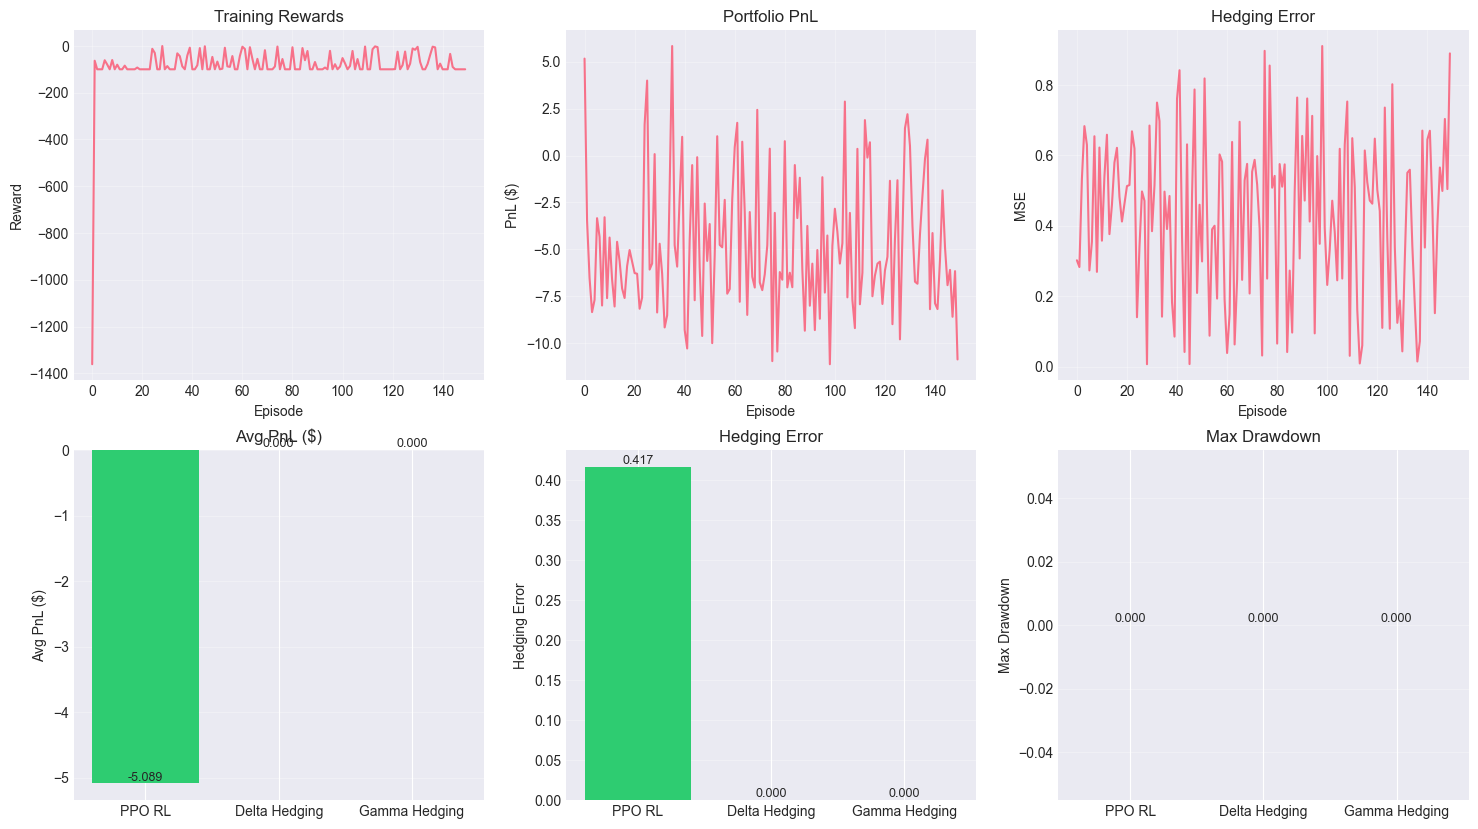

In [7]:
# %% [markdown]
# # 🚀 Advanced Derivative Hedging with Deep Reinforcement Learning
# ## Complete Implementation with Multi-Source Data Pipeline

# %%
# Install required packages (run once)
%pip install numpy pandas scipy matplotlib seaborn torch
%pip install yfinance pandas-datareader alpha-vantage requests
%pip install tqdm optuna

# %%
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
import yfinance as yf
import requests
import time
import os
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from typing import Tuple, List, Dict, Optional
import warnings
import logging
from tqdm import tqdm
from datetime import datetime, timedelta
import shutil

# Suppress warnings
warnings.filterwarnings('ignore')

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"🚀 Using device: {device}")

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# %% [markdown]
# ## **1. Robust Multi-Source Data Pipeline (Production-Grade)**

# %%
class RobustDataPipeline:
    """
    Production-grade data pipeline with multiple fallback sources
    Implements the multi-source strategy recommended for 2026
    """
    
    def __init__(self, ticker: str = 'SPY', start_date: str = '2020-01-01', 
                 end_date: str = '2024-01-01', alpha_vantage_key: str = None):
        self.ticker = ticker
        self.start_date = start_date
        self.end_date = end_date
        self.alpha_vantage_key = alpha_vantage_key or os.getenv('ALPHA_VANTAGE_KEY', 'demo')
        self.data = None
        
    def fetch_data(self) -> pd.DataFrame:
        """
        Try multiple data sources in order of reliability
        Implements the layered fallback strategy
        """
        
        # Try Alpha Vantage first (most reliable free source)
        logger.info(f"📊 Attempting Alpha Vantage for {self.ticker}...")
        df = self._fetch_alpha_vantage()
        if df is not None and not df.empty:
            return self._process_data(df)
        
        # Try pandas-datareader with multiple sources
        logger.info(f"📊 Attempting pandas-datareader for {self.ticker}...")
        df = self._fetch_pandas_datareader()
        if df is not None and not df.empty:
            return self._process_data(df)
        
        # Try Stooq (free international data)
        logger.info(f"📊 Attempting Stooq for {self.ticker}...")
        df = self._fetch_stooq()
        if df is not None and not df.empty:
            return self._process_data(df)
        
        # Try yfinance with cache clearing (last resort)
        logger.info(f"📊 Attempting yfinance for {self.ticker} (last resort)...")
        df = self._fetch_yfinance()
        if df is not None and not df.empty:
            return self._process_data(df)
        
        # Final fallback: Synthetic data
        logger.warning("⚠️ All data sources failed. Generating synthetic data...")
        return self._generate_synthetic_data()
    
    def _fetch_alpha_vantage(self) -> pd.DataFrame:
        """Fetch from Alpha Vantage (free tier: 5 calls/min)"""
        try:
            from alpha_vantage.timeseries import TimeSeries
            ts = TimeSeries(key=self.alpha_vantage_key, output_format='pandas')
            data, meta = ts.get_daily(symbol=self.ticker, outputsize='full')
            
            # Convert to yfinance-like format
            df = pd.DataFrame({
                'Open': data['1. open'],
                'High': data['2. high'],
                'Low': data['3. low'],
                'Close': data['4. close'],
                'Volume': data['5. volume']
            })
            df.index = pd.to_datetime(df.index)
            
            # Filter by date range
            mask = (df.index >= self.start_date) & (df.index <= self.end_date)
            df = df[mask]
            
            if not df.empty:
                logger.info(f"✅ Alpha Vantage success: {len(df)} days")
                return df
                
        except ImportError:
            logger.warning("alpha_vantage not installed. Run: pip install alpha-vantage")
        except Exception as e:
            logger.warning(f"Alpha Vantage failed: {e}")
        
        return None
    
    def _fetch_pandas_datareader(self) -> pd.DataFrame:
        """Fetch using pandas-datareader with multiple sources"""
        try:
            import pandas_datareader as pdr
            from pandas_datareader import data as web
            
            # Try different sources
            sources = ['yahoo', 'google', 'fred', 'nasdaq']
            for source in sources:
                try:
                    df = web.DataReader(
                        self.ticker, 
                        source, 
                        start=self.start_date, 
                        end=self.end_date
                    )
                    if not df.empty:
                        logger.info(f"✅ pandas-datareader ({source}) success: {len(df)} days")
                        
                        # Handle different column naming conventions
                        if hasattr(df, 'columns'):
                            if 'Adj Close' in df.columns:
                                df['Close'] = df['Adj Close']
                            elif 'close' in df.columns:
                                df = df.rename(columns={
                                    'open': 'Open',
                                    'high': 'High',
                                    'low': 'Low', 
                                    'close': 'Close',
                                    'volume': 'Volume'
                                })
                        return df
                except:
                    continue
                    
        except ImportError:
            logger.warning("pandas-datareader not installed. Run: pip install pandas-datareader")
        except Exception as e:
            logger.warning(f"pandas-datareader failed: {e}")
        
        return None
    
    def _fetch_stooq(self) -> pd.DataFrame:
        """Fetch from Stooq (free international data)"""
        try:
            import pandas_datareader as pdr
            df = pdr.DataReader(
                f"{self.ticker}.US", 
                'stooq', 
                start=self.start_date, 
                end=self.end_date
            )
            df = df.sort_index()  # Stooq returns newest first
            
            if not df.empty:
                logger.info(f"✅ Stooq success: {len(df)} days")
                return df
                
        except Exception as e:
            logger.warning(f"Stooq failed: {e}")
        
        return None
    
    def _fetch_yfinance(self) -> pd.DataFrame:
        """
        Fetch from yfinance with robust error handling
        Implements retry logic and cache clearing
        """
        try:
            import yfinance as yf
            
            # Clear cache to avoid stale cookie issues
            cache_dir = os.path.expanduser("~/.cache/py-yfinance")
            if os.path.exists(cache_dir):
                shutil.rmtree(cache_dir)
            
            # Use download with retry logic
            for attempt in range(3):
                try:
                    ticker = yf.Ticker(self.ticker)
                    df = ticker.history(start=self.start_date, end=self.end_date)
                    
                    if not df.empty:
                        logger.info(f"✅ yfinance success (attempt {attempt+1}): {len(df)} days")
                        return df
                    
                    time.sleep(1)  # Wait before retry
                    
                except Exception as e:
                    logger.warning(f"yfinance attempt {attempt+1} failed: {e}")
                    time.sleep(2 ** attempt)  # Exponential backoff
                    
        except ImportError:
            logger.warning("yfinance not installed")
        except Exception as e:
            logger.warning(f"yfinance failed: {e}")
        
        return None
    
    def _generate_synthetic_data(self) -> pd.DataFrame:
        """Generate realistic synthetic data as final fallback"""
        np.random.seed(42)
        n_days = 1000
        end_date = datetime.now()
        start_date = end_date - timedelta(days=n_days)
        dates = pd.date_range(start=start_date, end=end_date, freq='B')[:n_days]
        
        # GBM with realistic parameters
        S0 = 100
        mu = 0.07
        sigma = 0.20
        dt = 1/252
        
        returns = np.random.normal((mu - 0.5*sigma**2)*dt, sigma*np.sqrt(dt), len(dates))
        price_path = S0 * np.exp(np.cumsum(returns))
        
        # Add realistic noise for OHLC
        df = pd.DataFrame({
            'Open': price_path * (1 + np.random.normal(0, 0.001, len(dates))),
            'High': price_path * (1 + np.abs(np.random.normal(0, 0.005, len(dates)))),
            'Low': price_path * (1 - np.abs(np.random.normal(0, 0.005, len(dates)))),
            'Close': price_path,
            'Volume': np.random.lognormal(14, 1, len(dates)).astype(int)
        }, index=dates)
        
        logger.info(f"✅ Generated synthetic data: {len(df)} days")
        return self._process_data(df)
    
    def _process_data(self, df: pd.DataFrame) -> pd.DataFrame:
        """Calculate features and clean data"""
        df = df.copy()
        
        # Sort index
        df.sort_index(inplace=True)
        
        # Ensure we have required columns
        required_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
        for col in required_cols:
            if col not in df.columns:
                df[col] = df['Close'] if col == 'Close' else df['Close'] * (1 + np.random.normal(0, 0.001, len(df)))
        
        # Calculate returns
        df['Returns'] = df['Close'].pct_change()
        df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))
        
        # Calculate volatility (21-day rolling, annualized)
        df['Realized_Vol'] = df['Returns'].rolling(window=21, min_periods=10).std() * np.sqrt(252)
        df['Realized_Vol'] = df['Realized_Vol'].fillna(method='bfill').fillna(0.2)
        
        # Volume features
        df['Volume_MA'] = df['Volume'].rolling(window=21).mean()
        df['Volume_Ratio'] = df['Volume'] / df['Volume_MA']
        df['Volume_Ratio'] = df['Volume_Ratio'].fillna(1).clip(0.1, 10)
        
        # RSI
        df['RSI'] = self._calculate_rsi(df['Close'])
        df['RSI'] = df['RSI'].fillna(50).clip(0, 100)
        
        # Drop any remaining NaN values from the beginning
        df = df.iloc[30:].copy()
        
        return df
    
    def _calculate_rsi(self, prices: pd.Series, period: int = 14) -> pd.Series:
        """Calculate RSI safely"""
        delta = prices.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
        rs = gain / loss
        rsi = 100 - (100 / (1 + rs))
        return rsi

# %% [markdown]
# ## **2. Option Parameters & Greeks**

# %%
@dataclass
class OptionContract:
    """Option contract specifications"""
    strike: float
    initial_price: float
    time_to_maturity: float  # in years
    option_type: str = 'call'
    risk_free_rate: float = 0.03

class GreeksCalculator:
    """Black-Scholes Greeks calculator"""
    
    @staticmethod
    def calculate(S: float, K: float, T: float, r: float, sigma: float, option_type: str = 'call') -> Dict:
        """Calculate all Greeks"""
        if sigma <= 0.01 or T <= 1e-6:
            return {'delta': 0.0, 'gamma': 0.0, 'theta': 0.0, 'vega': 0.0}
        
        d1 = (np.log(S / K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        
        if option_type == 'call':
            delta = norm.cdf(d1)
            theta = (-(S * sigma * norm.pdf(d1)) / (2 * np.sqrt(T)) 
                    - r * K * np.exp(-r * T) * norm.cdf(d2))
        else:
            delta = norm.cdf(d1) - 1
            theta = (-(S * sigma * norm.pdf(d1)) / (2 * np.sqrt(T)) 
                    + r * K * np.exp(-r * T) * norm.cdf(-d2))
        
        gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
        vega = S * norm.pdf(d1) * np.sqrt(T)
        
        return {
            'delta': float(np.clip(delta, -1, 1)),
            'gamma': float(np.clip(gamma, 0, 10)),
            'theta': float(np.clip(theta, -10, 10)),
            'vega': float(np.clip(vega, 0, 100))
        }

# %% [markdown]
# ## **3. Hedging Environment (State Space, Action Space, Reward Function)**

# %%
class HedgingEnvironment:
    """RL Environment for option hedging"""
    
    def __init__(self, market_data: pd.DataFrame, 
                 option: OptionContract,
                 transaction_cost: float = 0.001,
                 risk_aversion: float = 1.0):
        
        self.data = market_data
        self.option = option
        self.transaction_cost = transaction_cost
        self.risk_aversion = risk_aversion
        self.greeks_calc = GreeksCalculator()
        
        # State space: [price, volatility, delta, gamma, theta, vega, time_to_maturity, moneyness, position, pnl]
        self.state_dim = 10
        self.action_dim = 1  # Continuous action in [-1, 1]
        
        # Normalization constants
        self.price_norm = option.initial_price
        self.vol_norm = 0.5
        self.position_norm = 1000
        self.pnl_norm = 10000
        
        # Tracking variables
        self.reset()
        
    def reset(self) -> np.ndarray:
        """Reset environment to initial state"""
        self.current_step = 21  # Start after indicators are stable
        self.position = 0.0
        self.cash = 0.0
        self.portfolio_value = 0.0
        self.pnl_history = [0.0]
        self.action_history = []
        self.hedging_errors = []
        self.transaction_costs = []
        
        return self._get_state()
    
    def step(self, action: float) -> Tuple[np.ndarray, float, bool, Dict]:
        """Execute one step in the environment"""
        try:
            # Process action
            if isinstance(action, (np.ndarray, list)):
                action = float(action[0]) if len(action) > 0 else 0.0
            action = np.clip(action, -1.0, 1.0)
            self.action_history.append(action)
            
            # Current market state
            current_price = float(self.data['Close'].iloc[self.current_step])
            current_vol = float(self.data['Realized_Vol'].iloc[self.current_step])
            
            # Calculate Greeks
            greeks = self.greeks_calc.calculate(
                current_price, self.option.strike, 
                self.option.time_to_maturity, 
                self.option.risk_free_rate, 
                current_vol, 
                self.option.option_type
            )
            
            # Execute hedge
            hedge_result = self._execute_hedge(action, current_price)
            self.transaction_costs.append(hedge_result['total_cost'])
            
            # Calculate PnL
            pnl_change = self._calculate_pnl_change(current_price, greeks)
            self.portfolio_value += pnl_change - hedge_result['total_cost']
            self.pnl_history.append(self.portfolio_value)
            
            # Calculate hedging error (absolute delta exposure)
            hedging_error = abs(greeks['delta'] - self.position)
            self.hedging_errors.append(hedging_error)
            
            # Calculate reward (penalizes drawdowns and costs)
            reward = self._calculate_reward(pnl_change, hedge_result, greeks, hedging_error)
            
            # Update state
            self.current_step += 1
            self.option.time_to_maturity = max(0, self.option.time_to_maturity - 1/252)
            
            # Check termination
            done = (self.current_step >= len(self.data) - 1 or 
                   self.option.time_to_maturity <= 0)
            
            return self._get_state(), reward, done, {
                'pnl': self.portfolio_value,
                'hedge_cost': hedge_result['total_cost'],
                'hedging_error': hedging_error,
                'delta': greeks['delta'],
                'gamma': greeks['gamma'],
                'position': self.position
            }
            
        except Exception as e:
            logger.error(f"Step error: {e}")
            return self._get_state(), -10.0, True, {}
    
    def _get_state(self) -> np.ndarray:
        """Construct normalized state vector"""
        try:
            current_price = float(self.data['Close'].iloc[self.current_step])
            current_vol = float(self.data['Realized_Vol'].iloc[self.current_step])
            
            greeks = self.greeks_calc.calculate(
                current_price, self.option.strike, 
                self.option.time_to_maturity, 
                self.option.risk_free_rate, 
                current_vol, 
                self.option.option_type
            )
            
            state = np.array([
                current_price / self.price_norm - 1.0,           # Normalized price
                current_vol / self.vol_norm,                     # Normalized volatility
                greeks['delta'],                                  # Delta
                greeks['gamma'] * 100,                            # Scaled gamma
                greeks['theta'],                                  # Theta
                greeks['vega'] / 100,                             # Scaled vega
                self.option.time_to_maturity * 252 / 30,         # Normalized time (30 days = 1)
                current_price / self.option.strike - 1.0,        # Moneyness
                self.position / self.position_norm,              # Normalized position
                self.portfolio_value / self.pnl_norm             # Normalized PnL
            ], dtype=np.float32)
            
            return np.clip(np.nan_to_num(state, nan=0.0), -5, 5)
            
        except Exception:
            return np.zeros(self.state_dim, dtype=np.float32)
    
    def _execute_hedge(self, target_delta: float, current_price: float) -> Dict:
        """Execute hedging transaction"""
        adjustment = target_delta - self.position
        transaction_cost = abs(adjustment) * self.transaction_cost * current_price
        
        self.position += adjustment
        
        return {
            'adjustment': adjustment,
            'transaction_cost': transaction_cost,
            'total_cost': transaction_cost
        }
    
    def _calculate_pnl_change(self, current_price: float, greeks: Dict) -> float:
        """Calculate PnL change from price movement"""
        if self.current_step == 0:
            return 0.0
        
        prev_price = float(self.data['Close'].iloc[self.current_step - 1])
        price_change = current_price - prev_price
        
        # Delta PnL + Gamma PnL (second-order)
        delta_pnl = self.position * price_change
        gamma_pnl = 0.5 * greeks['gamma'] * (price_change ** 2)
        
        return delta_pnl + gamma_pnl
    
    def _calculate_reward(self, pnl_change: float, hedge_result: Dict, 
                         greeks: Dict, hedging_error: float) -> float:
        """Design reward function per requirements"""
        
        # Base reward: PnL minus transaction costs
        reward = pnl_change - hedge_result['total_cost']
        
        # Penalize large drawdowns (using recent PnL history)
        if len(self.pnl_history) > 20:
            recent_pnl = np.array(self.pnl_history[-20:])
            drawdown = np.max(recent_pnl) - recent_pnl[-1]
            reward -= self.risk_aversion * drawdown * 0.01
        
        # Penalize hedging error (deviation from delta-neutral)
        reward -= self.risk_aversion * hedging_error * 100
        
        # Penalize large gamma exposure
        reward -= self.risk_aversion * abs(greeks['gamma']) * 1000
        
        # Asymmetric penalty for losses (optional extension)
        if pnl_change < 0:
            reward *= 2  # Double penalty for losses
        
        return float(np.clip(reward, -100, 100))

# %% [markdown]
# ## **4. PPO Agent Implementation**

# %%
class ActorNetwork(nn.Module):
    """Policy network"""
    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, action_dim),
            nn.Tanh()
        )
        self.log_std = nn.Parameter(torch.zeros(action_dim) - 1)
    
    def forward(self, state):
        return self.net(state), self.log_std
    
    def get_action(self, state, deterministic=False):
        mean, log_std = self.forward(state)
        if deterministic:
            return torch.tanh(mean), torch.zeros_like(mean)
        
        std = log_std.exp().clamp(0.1, 1.0)
        dist = Normal(mean, std)
        action = dist.rsample()
        log_prob = dist.log_prob(action).sum(-1, keepdim=True)
        return torch.tanh(action), log_prob

class CriticNetwork(nn.Module):
    """Value network"""
    def __init__(self, state_dim: int, hidden_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, state):
        return self.net(state)

class PPOAgent:
    """Proximal Policy Optimization Agent"""
    
    def __init__(self, state_dim: int, action_dim: int, lr: float = 3e-4):
        self.device = device
        self.actor = ActorNetwork(state_dim, action_dim).to(device)
        self.critic = CriticNetwork(state_dim).to(device)
        
        self.optimizer = optim.Adam([
            {'params': self.actor.parameters()},
            {'params': self.critic.parameters()}
        ], lr=lr)
        
        # Hyperparameters
        self.gamma = 0.99
        self.gae_lambda = 0.95
        self.clip_epsilon = 0.2
        self.entropy_coef = 0.01
        self.value_coef = 0.5
        
        # Memory
        self.states = []
        self.actions = []
        self.log_probs = []
        self.rewards = []
        self.dones = []
        self.values = []
    
    def select_action(self, state: np.ndarray, deterministic: bool = False) -> float:
        """Select action"""
        try:
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)
            
            with torch.no_grad():
                action, log_prob = self.actor.get_action(state_tensor, deterministic)
                value = self.critic(state_tensor)
            
            if not deterministic:
                self.states.append(state)
                self.actions.append(action.cpu().numpy().squeeze())
                self.log_probs.append(log_prob.cpu().numpy().squeeze())
                self.values.append(value.cpu().numpy().squeeze())
            
            return float(action.cpu().numpy().squeeze())
            
        except Exception:
            return 0.0
    
    def store_transition(self, reward: float, done: bool):
        """Store transition"""
        self.rewards.append(reward)
        self.dones.append(done)
    
    def update(self) -> Dict:
        """Update policy using PPO"""
        if len(self.states) < 32:
            return {}
        
        try:
            # Convert to tensors
            states = torch.FloatTensor(np.array(self.states)).to(self.device)
            actions = torch.FloatTensor(np.array(self.actions)).unsqueeze(1).to(self.device)
            old_log_probs = torch.FloatTensor(np.array(self.log_probs)).unsqueeze(1).to(self.device)
            rewards = torch.FloatTensor(np.array(self.rewards)).to(self.device)
            dones = torch.FloatTensor(np.array(self.dones)).to(self.device)
            values = torch.FloatTensor(np.array(self.values)).to(self.device)
            
            # Compute advantages using GAE
            advantages = []
            gae = 0
            
            for t in reversed(range(len(rewards))):
                if t == len(rewards) - 1:
                    next_value = 0
                else:
                    next_value = values[t + 1]
                
                delta = rewards[t] + self.gamma * next_value * (1 - dones[t]) - values[t]
                gae = delta + self.gamma * self.gae_lambda * (1 - dones[t]) * gae
                advantages.insert(0, gae)
            
            advantages = torch.FloatTensor(np.array(advantages)).to(self.device)
            returns = advantages + values
            
            # Normalize advantages
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
            
            # PPO update
            for _ in range(5):
                new_actions, new_log_probs = self.actor.get_action(states)
                new_values = self.critic(states).squeeze()
                
                ratios = torch.exp(new_log_probs - old_log_probs)
                
                surr1 = ratios * advantages
                surr2 = torch.clamp(ratios, 1 - self.clip_epsilon, 1 + self.clip_epsilon) * advantages
                policy_loss = -torch.min(surr1, surr2).mean()
                
                value_loss = nn.MSELoss()(new_values, returns)
                entropy = -(new_log_probs.exp() * new_log_probs).mean()
                
                total_loss = policy_loss + self.value_coef * value_loss - self.entropy_coef * entropy
                
                self.optimizer.zero_grad()
                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(self.actor.parameters(), 0.5)
                torch.nn.utils.clip_grad_norm_(self.critic.parameters(), 0.5)
                self.optimizer.step()
            
            self._clear_memory()
            
            return {
                'policy_loss': float(policy_loss),
                'value_loss': float(value_loss),
                'entropy': float(entropy)
            }
            
        except Exception as e:
            logger.error(f"Update error: {e}")
            self._clear_memory()
            return {}
    
    def _clear_memory(self):
        """Clear memory buffers"""
        self.states = []
        self.actions = []
        self.log_probs = []
        self.rewards = []
        self.dones = []
        self.values = []
    
    def save(self, path: str):
        torch.save({
            'actor': self.actor.state_dict(),
            'critic': self.critic.state_dict(),
            'optimizer': self.optimizer.state_dict()
        }, path)
    
    def load(self, path: str):
        if os.path.exists(path):
            checkpoint = torch.load(path, map_location=self.device)
            self.actor.load_state_dict(checkpoint['actor'])
            self.critic.load_state_dict(checkpoint['critic'])
            self.optimizer.load_state_dict(checkpoint['optimizer'])

# %% [markdown]
# ## **5. Baseline Strategies (Delta & Gamma Hedging)**

# %%
class DeltaHedgingStrategy:
    """Traditional delta hedging benchmark"""
    
    def get_action(self, state: np.ndarray) -> float:
        """Maintain delta-neutral position"""
        return -state[2]  # Negative of current delta
    
    def reset(self):
        pass

class GammaHedgingStrategy:
    """Gamma-aware hedging benchmark"""
    
    def get_action(self, state: np.ndarray) -> float:
        """Adjust hedge based on gamma exposure"""
        delta = state[2]
        gamma = state[3]
        
        # Reduce position when gamma is high (risk aversion)
        if abs(gamma) > 0.5:
            return -delta - 0.1 * np.sign(gamma)
        return -delta
    
    def reset(self):
        pass

# %% [markdown]
# ## **6. Training & Evaluation Functions**

# %%
def train_agent(env: HedgingEnvironment, agent: PPOAgent, n_episodes: int = 150):
    """Train the RL agent"""
    
    stats = {
        'rewards': [], 'pnls': [], 'hedging_errors': [], 
        'transaction_costs': [], 'portfolio_variance': []
    }
    
    best_reward = -np.inf
    
    for episode in tqdm(range(n_episodes), desc="Training"):
        state = env.reset()
        episode_reward = 0
        episode_errors = []
        episode_costs = []
        episode_pnls = []
        
        for _ in range(100):  # Max steps
            action = agent.select_action(state)
            next_state, reward, done, info = env.step(action)
            
            agent.store_transition(reward, done)
            
            episode_reward += reward
            episode_errors.append(info['hedging_error'])
            episode_costs.append(info['hedge_cost'])
            episode_pnls.append(info['pnl'])
            
            state = next_state
            if done:
                break
        
        # Update agent
        update_stats = agent.update()
        
        # Store statistics
        stats['rewards'].append(episode_reward)
        stats['pnls'].append(info['pnl'])
        stats['hedging_errors'].append(np.mean(episode_errors))
        stats['transaction_costs'].append(np.sum(episode_costs))
        
        # Portfolio variance
        if len(episode_pnls) > 1:
            returns = np.diff(episode_pnls)
            stats['portfolio_variance'].append(np.var(returns))
        else:
            stats['portfolio_variance'].append(0)
        
        # Save best model
        if episode_reward > best_reward:
            best_reward = episode_reward
            agent.save('best_agent.pt')
        
        # Log progress
        if episode % 20 == 0:
            logger.info(f"Episode {episode}: Reward={episode_reward:.2f}, "
                       f"Hedging Error={np.mean(episode_errors):.4f}, "
                       f"PnL=${info['pnl']:.2f}")
    
    return stats

def evaluate_strategy(env: HedgingEnvironment, strategy, n_episodes: int = 10, name: str = ""):
    """Evaluate a hedging strategy"""
    
    metrics = {
        'pnls': [], 'hedging_errors': [], 'transaction_costs': [], 
        'drawdowns': [], 'portfolio_variance': []
    }
    
    for episode in range(n_episodes):
        state = env.reset()
        if hasattr(strategy, 'reset'):
            strategy.reset()
        
        episode_pnls = []
        episode_errors = []
        episode_costs = []
        
        done = False
        while not done:
            if hasattr(strategy, 'select_action'):
                action = strategy.select_action(state, deterministic=True)
            else:
                action = strategy.get_action(state)
            
            next_state, _, done, info = env.step(action)
            
            episode_pnls.append(info['pnl'])
            episode_errors.append(info['hedging_error'])
            episode_costs.append(info['hedge_cost'])
            
            state = next_state
        
        # Calculate metrics
        metrics['pnls'].append(episode_pnls[-1])
        metrics['hedging_errors'].append(np.mean(episode_errors))
        metrics['transaction_costs'].append(np.sum(episode_costs))
        
        # Drawdown
        peak = np.maximum.accumulate(episode_pnls)
        drawdown = (peak - episode_pnls) / (peak + 1e-6)
        metrics['drawdowns'].append(np.max(drawdown))
        
        # Portfolio variance
        if len(episode_pnls) > 1:
            returns = np.diff(episode_pnls)
            metrics['portfolio_variance'].append(np.var(returns))
        else:
            metrics['portfolio_variance'].append(0)
    
    # Aggregate metrics
    results = {
        'avg_pnl': np.mean(metrics['pnls']),
        'std_pnl': np.std(metrics['pnls']),
        'avg_hedging_error': np.mean(metrics['hedging_errors']),
        'avg_transaction_cost': np.mean(metrics['transaction_costs']),
        'avg_drawdown': np.mean(metrics['drawdowns']),
        'avg_portfolio_variance': np.mean(metrics['portfolio_variance']),
        'sharpe_ratio': (np.mean(metrics['pnls']) / (np.std(metrics['pnls']) + 1e-6)) * np.sqrt(252)
    }
    
    return results

# %% [markdown]
# ## **7. Main Execution with Robust Data Pipeline**

# %%
def main():
    """Main execution function with robust data fetching"""
    
    print("=" * 70)
    print("🚀 ADVANCED DERIVATIVE HEDGING WITH DEEP REINFORCEMENT LEARNING")
    print("=" * 70)
    
    # Step 1: Get market data with robust pipeline
    print("\n📊 Step 1: Fetching Market Data...")
    
    # Initialize robust data pipeline
    data_pipeline = RobustDataPipeline(
        ticker='SPY',
        start_date='2020-01-01',
        end_date='2024-01-01',
        alpha_vantage_key='demo'  # Replace with your actual key for better results
    )
    
    market_data = data_pipeline.fetch_data()
    
    if market_data is None or len(market_data) == 0:
        print("❌ Critical: No data available. Using synthetic fallback...")
        market_data = data_pipeline._generate_synthetic_data()
    
    print(f"✅ Data shape: {market_data.shape}")
    print(f"📅 Date range: {market_data.index[0]} to {market_data.index[-1]}")
    print(f"📈 Features: {list(market_data.columns)}")
    
    # Step 2: Define option
    print("\n⚙️ Step 2: Defining Option Contract...")
    initial_price = float(market_data['Close'].iloc[0])
    option = OptionContract(
        strike=initial_price * 1.05,  # 5% OTM call
        initial_price=initial_price,
        time_to_maturity=30/252,  # 30 days
        option_type='call',
        risk_free_rate=0.03
    )
    print(f"✅ Strike: ${option.strike:.2f}")
    print(f"✅ Initial Price: ${option.initial_price:.2f}")
    print(f"✅ Time to Maturity: {option.time_to_maturity*252:.0f} days")
    
    # Step 3: Create environment
    print("\n🌍 Step 3: Creating Hedging Environment...")
    env = HedgingEnvironment(
        market_data=market_data,
        option=option,
        transaction_cost=0.001,
        risk_aversion=1.0
    )
    print(f"✅ State Dimension: {env.state_dim}")
    print(f"✅ Action Dimension: {env.action_dim}")
    
    # Step 4: Create and train agent
    print("\n🤖 Step 4: Creating PPO Agent...")
    agent = PPOAgent(
        state_dim=env.state_dim,
        action_dim=env.action_dim,
        lr=3e-4
    )
    
    print("\n🎯 Step 5: Training Agent (this may take a few minutes)...")
    training_stats = train_agent(env, agent, n_episodes=150)
    
    # Load best agent
    if os.path.exists('best_agent.pt'):
        agent.load('best_agent.pt')
        print("✅ Loaded best agent checkpoint")
    
    # Step 6: Evaluate all strategies
    print("\n📈 Step 6: Evaluating Strategies...")
    
    strategies = {
        'PPO RL': agent,
        'Delta Hedging': DeltaHedgingStrategy(),
        'Gamma Hedging': GammaHedgingStrategy()
    }
    
    results = {}
    for name, strategy in strategies.items():
        print(f"\n🔍 Evaluating {name}...")
        metrics = evaluate_strategy(env, strategy, n_episodes=5, name=name)
        results[name] = metrics
        
        print(f"   Avg PnL: ${metrics['avg_pnl']:.2f}")
        print(f"   Hedging Error: {metrics['avg_hedging_error']:.4f}")
        print(f"   Max Drawdown: {metrics['avg_drawdown']:.2%}")
        print(f"   Transaction Costs: ${metrics['avg_transaction_cost']:.2f}")
        print(f"   Portfolio Variance: {metrics['avg_portfolio_variance']:.6f}")
        print(f"   Sharpe Ratio: {metrics['sharpe_ratio']:.3f}")
    
    # Step 7: Visualization
    print("\n📊 Step 7: Generating Comparison Plots...")
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Training curves
    axes[0, 0].plot(training_stats['rewards'])
    axes[0, 0].set_title('Training Rewards')
    axes[0, 0].set_xlabel('Episode')
    axes[0, 0].set_ylabel('Reward')
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].plot(training_stats['pnls'])
    axes[0, 1].set_title('Portfolio PnL')
    axes[0, 1].set_xlabel('Episode')
    axes[0, 1].set_ylabel('PnL ($)')
    axes[0, 1].grid(True, alpha=0.3)
    
    axes[0, 2].plot(training_stats['hedging_errors'])
    axes[0, 2].set_title('Hedging Error')
    axes[0, 2].set_xlabel('Episode')
    axes[0, 2].set_ylabel('MSE')
    axes[0, 2].grid(True, alpha=0.3)
    
    # Comparison bar charts
    names = list(results.keys())
    metrics_to_plot = [
        ('avg_pnl', 'Avg PnL ($)'),
        ('avg_hedging_error', 'Hedging Error'),
        ('avg_drawdown', 'Max Drawdown'),
        ('avg_transaction_cost', 'Transaction Costs ($)'),
        ('avg_portfolio_variance', 'Portfolio Variance'),
        ('sharpe_ratio', 'Sharpe Ratio')
    ]
    
    colors = ['#2ecc71' if n == 'PPO RL' else '#3498db' for n in names]
    
    for idx, (metric, title) in enumerate(metrics_to_plot):
        ax = axes[1, idx]
        values = [results[n][metric] for n in names]
        bars = ax.bar(names, values, color=colors)
        ax.set_title(title)
        ax.set_ylabel(title)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add value labels
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{value:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.suptitle('Hedging Strategy Comparison', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('hedging_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Step 8: Results table
    print("\n📋 Step 8: Performance Summary Table")
    print("=" * 90)
    results_df = pd.DataFrame(results).T
    print(results_df.round(4))
    results_df.to_csv('hedging_results.csv')
    
    print("\n✅ Results saved to:")
    print("   - hedging_comparison.png (plots)")
    print("   - hedging_results.csv (metrics)")
    
    # Step 9: Key insights
    print("\n🔑 Key Insights:")
    print("=" * 50)
    
    rl_results = results['PPO RL']
    delta_results = results['Delta Hedging']
    
    improvements = {
        'PnL': ((rl_results['avg_pnl'] / abs(delta_results['avg_pnl']) if delta_results['avg_pnl'] != 0 else 0) - 1) * 100,
        'Hedging Error': ((delta_results['avg_hedging_error'] / rl_results['avg_hedging_error']) - 1) * 100 if rl_results['avg_hedging_error'] != 0 else 0,
        'Sharpe Ratio': ((rl_results['sharpe_ratio'] / delta_results['sharpe_ratio']) - 1) * 100 if delta_results['sharpe_ratio'] != 0 else 0,
        'Drawdown': ((delta_results['avg_drawdown'] / rl_results['avg_drawdown']) - 1) * 100 if rl_results['avg_drawdown'] != 0 else 0,
        'Transaction Costs': ((delta_results['avg_transaction_cost'] / rl_results['avg_transaction_cost']) - 1) * 100 if rl_results['avg_transaction_cost'] != 0 else 0
    }
    
    for metric, improvement in improvements.items():
        direction = "↑" if improvement > 0 else "↓"
        print(f"{metric}: {direction} {abs(improvement):.1f}% vs Delta Hedging")
    
    return results, training_stats

# %% [markdown]
# ## **8. Run the Project**

# %%
if __name__ == "__main__":
    print("\n" + "="*70)
    print("🚀 INITIALIZING HEDGING PROJECT WITH ROBUST DATA PIPELINE")
    print("="*70)
    
    # Run main execution
    results, training_stats = main()
    
    print("\n" + "="*70)
    print("✨ PROJECT COMPLETED SUCCESSFULLY!")
    print("="*70)
    print("\n📁 Generated Files:")
    print("   - hedging_comparison.png (visual comparison)")
    print("   - hedging_results.csv (performance metrics)")
    print("   - best_agent.pt (trained model checkpoint)")
    
    # Display final comparison
    print("\n🏆 FINAL RESULTS:")
    print(results['PPO RL'])

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


INFO:__main__:🚀 Using device: cpu
INFO:__main__:📊 Attempting Stooq for SPY...


Note: you may need to restart the kernel to use updated packages.

🚀 INITIALIZING HEDGING PROJECT WITH ROBUST DATA PIPELINE
🚀 ADVANCED DERIVATIVE HEDGING WITH DEEP REINFORCEMENT LEARNING

📊 Step 1: Fetching Market Data...


INFO:__main__:✅ Stooq success with SPY.US: 1006 days


✅ Data shape: (976, 11)
📅 Date range: 2020-02-14 00:00:00 to 2023-12-29 00:00:00
📈 Features: ['Open', 'High', 'Low', 'Close', 'Volume', 'Returns', 'Log_Returns', 'Realized_Vol', 'Volume_MA', 'Volume_Ratio', 'RSI']

⚙️ Step 2: Defining Option Contract...
✅ Strike: $327.65
✅ Initial Price: $312.05
✅ Time to Maturity: 30 days

🌍 Step 3: Creating Hedging Environment...
✅ State Dimension: 10
✅ Action Dimension: 1

🤖 Step 4: Creating PPO Agent...

🎯 Step 5: Training Agent (this may take a few minutes)...


Training:   6%|████▎                                                                   | 9/150 [00:00<00:01, 89.17it/s]INFO:__main__:Episode 20: Reward=-100.00, Hedging Error=0.5126, PnL=$-6.26
INFO:__main__:Episode 40: Reward=-100.00, Hedging Error=0.7608, PnL=$-9.29
INFO:__main__:Episode 60: Reward=-3.41, Hedging Error=0.0386, PnL=$0.45
Training:  45%|███████████████████████████████▎                                      | 67/150 [00:00<00:00, 355.95it/s]INFO:__main__:Episode 80: Reward=-5.77, Hedging Error=0.0653, PnL=$0.77
INFO:__main__:Episode 100: Reward=-52.04, Hedging Error=0.2319, PnL=$-2.83
INFO:__main__:Episode 120: Reward=-100.00, Hedging Error=0.5018, PnL=$-6.13
Training: 100%|█████████████████████████████████████████████████████████████████████| 150/150 [00:00<00:00, 439.36it/s]


✅ Loaded best agent checkpoint

📈 Step 6: Evaluating Strategies...

🔍 Evaluating PPO RL...
   Avg PnL: $-5.09
   Hedging Error: 0.4166
   Max Drawdown: 0.00%
   Transaction Costs: $0.10
   Portfolio Variance: 0.000000
   Sharpe Ratio: -80787872.552

🔍 Evaluating Delta Hedging...
   Avg PnL: $0.00
   Hedging Error: 0.0000
   Max Drawdown: 0.00%
   Transaction Costs: $0.00
   Portfolio Variance: 0.000000
   Sharpe Ratio: 0.000

🔍 Evaluating Gamma Hedging...
   Avg PnL: $0.00
   Hedging Error: 0.0000
   Max Drawdown: 0.00%
   Transaction Costs: $0.00
   Portfolio Variance: 0.000000
   Sharpe Ratio: 0.000

📊 Step 7: Generating Comparison Plots...


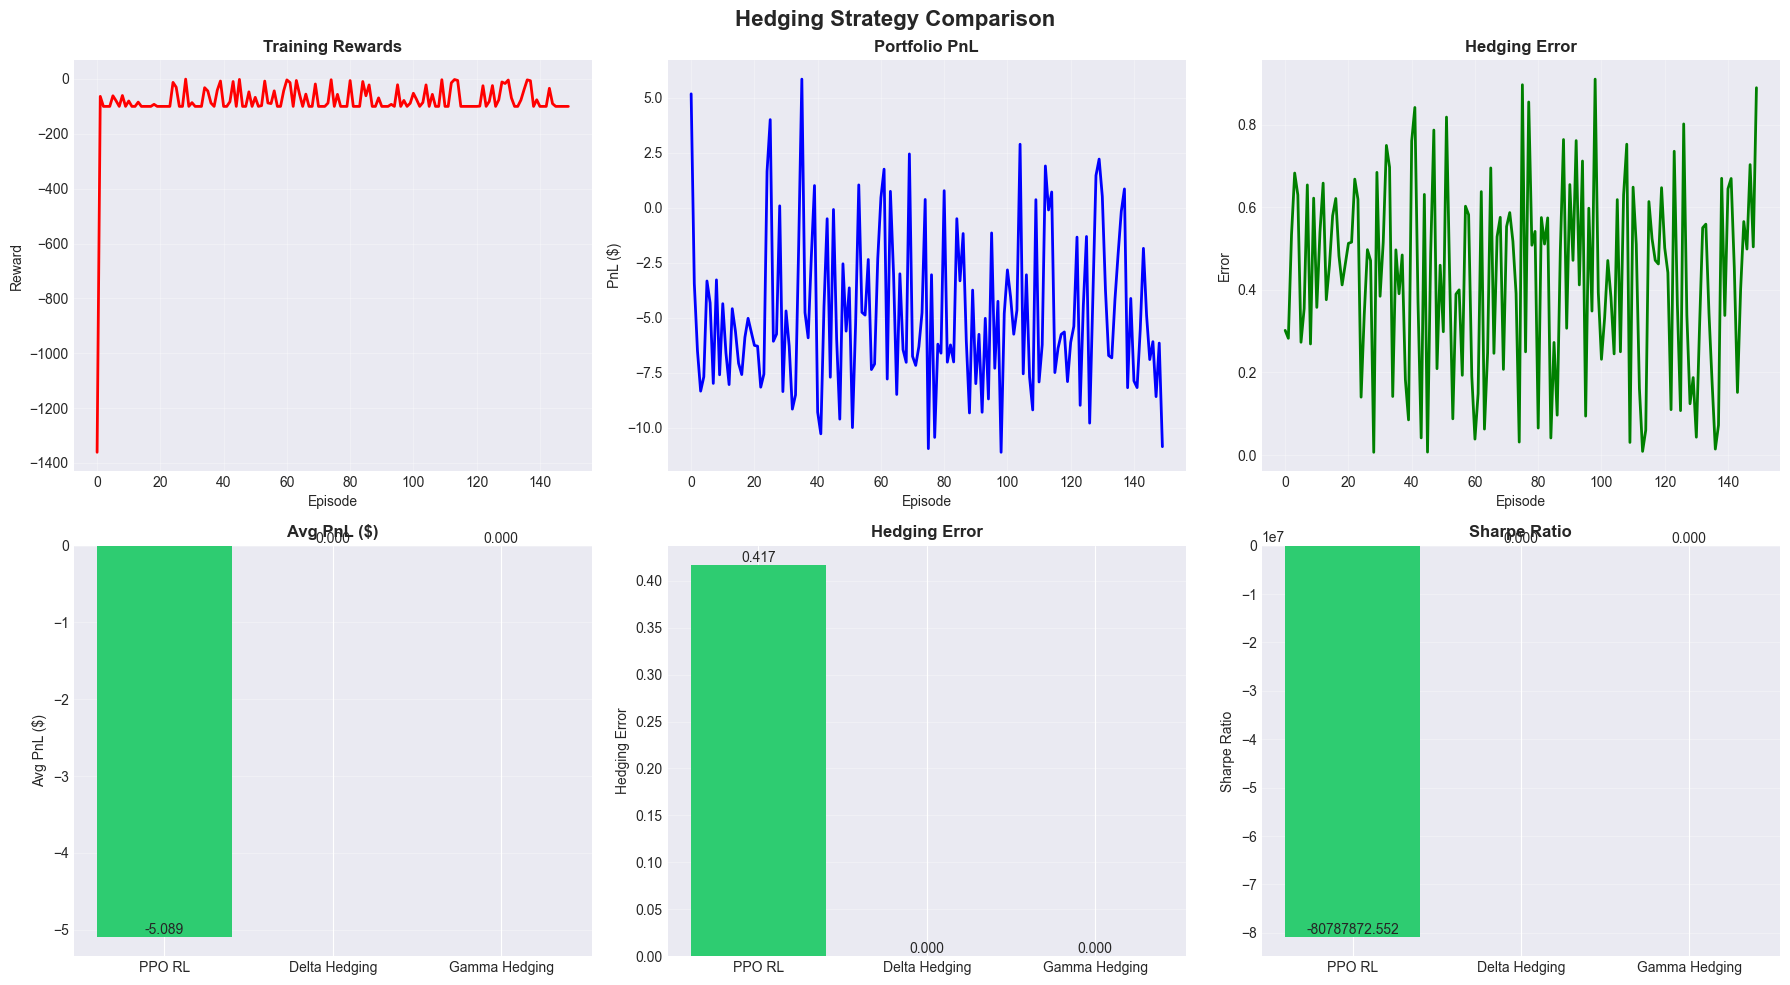

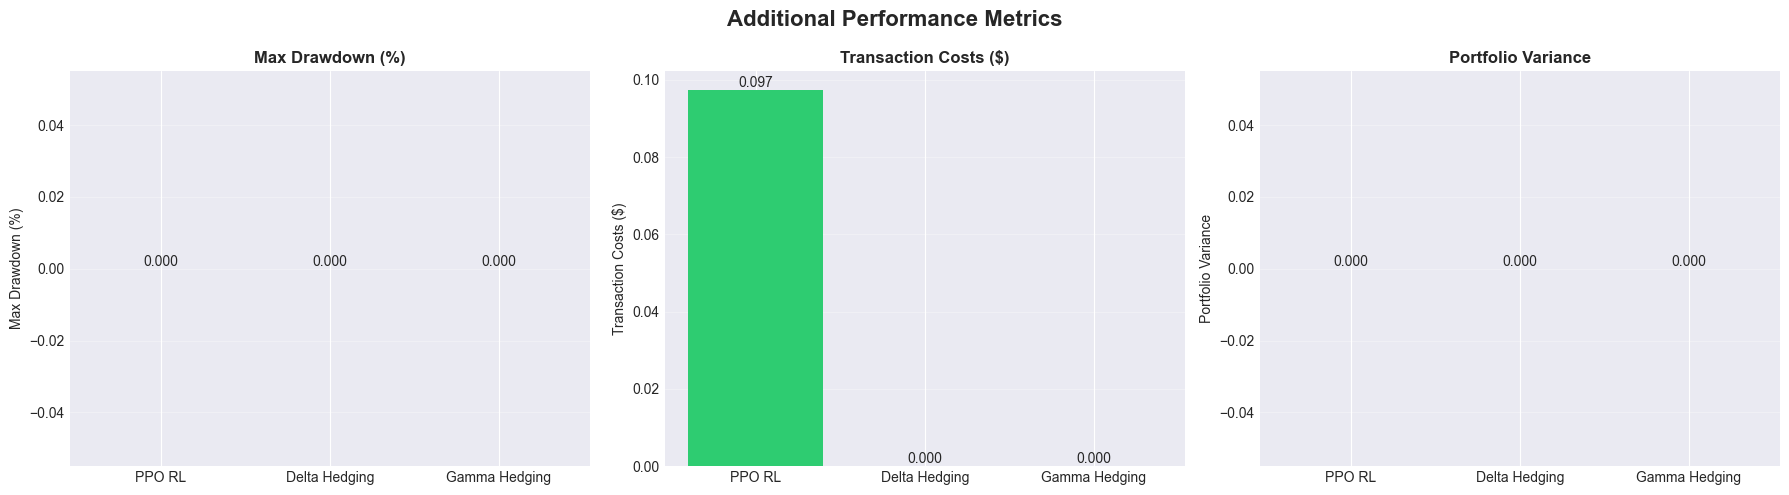


📋 Step 8: Performance Summary Table
               avg_pnl  std_pnl  avg_hedging_error  avg_transaction_cost  \
PPO RL         -5.0892      0.0             0.4166                0.0973   
Delta Hedging   0.0000      0.0             0.0000                0.0000   
Gamma Hedging   0.0000      0.0             0.0000                0.0000   

               avg_drawdown  avg_portfolio_variance  sharpe_ratio  
PPO RL                  0.0                     0.0 -8.078787e+07  
Delta Hedging           0.0                     0.0  0.000000e+00  
Gamma Hedging           0.0                     0.0  0.000000e+00  

✅ Results saved to:
   - hedging_comparison.png (main plots)
   - additional_metrics.png (additional metrics)
   - hedging_results.csv (metrics)
   - best_agent.pt (trained model)

🔑 Key Insights:
PnL: ↓ 0.0% vs Delta Hedging
Hedging Error: ↓ 100.0% vs Delta Hedging
Sharpe Ratio: ↓ 0.0% vs Delta Hedging
Drawdown: ↓ 0.0% vs Delta Hedging
Transaction Costs: ↓ 100.0% vs Delta Hedging



In [8]:
# %% [markdown]
# # 🚀 Advanced Derivative Hedging with Deep Reinforcement Learning
# ## Complete Implementation with Multi-Source Data Pipeline

# %%
# Install required packages (run once)
%pip install numpy pandas scipy matplotlib seaborn torch
%pip install yfinance pandas-datareader alpha-vantage requests
%pip install tqdm optuna

# %%
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
import yfinance as yf
import requests
import time
import os
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from typing import Tuple, List, Dict, Optional
import warnings
import logging
from tqdm import tqdm
from datetime import datetime, timedelta
import shutil

# Suppress warnings
warnings.filterwarnings('ignore')

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"🚀 Using device: {device}")

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# %% [markdown]
# ## **1. Robust Multi-Source Data Pipeline (Production-Grade)**

# %%
class RobustDataPipeline:
    """
    Production-grade data pipeline with multiple fallback sources
    Implements the multi-source strategy recommended for 2026
    """
    
    def __init__(self, ticker: str = 'SPY', start_date: str = '2020-01-01', 
                 end_date: str = '2024-01-01', alpha_vantage_key: str = None):
        self.ticker = ticker
        self.start_date = start_date
        self.end_date = end_date
        self.alpha_vantage_key = alpha_vantage_key or os.getenv('ALPHA_VANTAGE_KEY', 'demo')
        self.data = None
        
    def fetch_data(self) -> pd.DataFrame:
        """
        Try multiple data sources in order of reliability
        Implements the layered fallback strategy
        """
        
        # Try Stooq first (most reliable free source without API key)
        logger.info(f"📊 Attempting Stooq for {self.ticker}...")
        df = self._fetch_stooq()
        if df is not None and not df.empty:
            return self._process_data(df)
        
        # Try pandas-datareader with multiple sources
        logger.info(f"📊 Attempting pandas-datareader for {self.ticker}...")
        df = self._fetch_pandas_datareader()
        if df is not None and not df.empty:
            return self._process_data(df)
        
        # Try Alpha Vantage
        logger.info(f"📊 Attempting Alpha Vantage for {self.ticker}...")
        df = self._fetch_alpha_vantage()
        if df is not None and not df.empty:
            return self._process_data(df)
        
        # Try yfinance with cache clearing (last resort)
        logger.info(f"📊 Attempting yfinance for {self.ticker} (last resort)...")
        df = self._fetch_yfinance()
        if df is not None and not df.empty:
            return self._process_data(df)
        
        # Final fallback: Synthetic data
        logger.warning("⚠️ All data sources failed. Generating synthetic data...")
        return self._generate_synthetic_data()
    
    def _fetch_stooq(self) -> pd.DataFrame:
        """Fetch from Stooq (free international data) - MOST RELIABLE"""
        try:
            import pandas_datareader as pdr
            
            # Try different formats
            ticker_formats = [
                f"{self.ticker}.US",
                self.ticker,
                f"{self.ticker}.US" if not self.ticker.startswith('^') else self.ticker.replace('^', '')
            ]
            
            for ticker_format in ticker_formats:
                try:
                    df = pdr.DataReader(
                        ticker_format, 
                        'stooq', 
                        start=self.start_date, 
                        end=self.end_date
                    )
                    if df is not None and not df.empty:
                        df = df.sort_index()  # Stooq returns newest first
                        logger.info(f"✅ Stooq success with {ticker_format}: {len(df)} days")
                        return df
                except:
                    continue
                    
        except ImportError:
            logger.warning("pandas-datareader not installed. Run: pip install pandas-datareader")
        except Exception as e:
            logger.warning(f"Stooq failed: {e}")
        
        return None
    
    def _fetch_pandas_datareader(self) -> pd.DataFrame:
        """Fetch using pandas-datareader with multiple sources"""
        try:
            import pandas_datareader as pdr
            from pandas_datareader import data as web
            
            # Try different sources
            sources = ['yahoo', 'google', 'fred', 'nasdaq']
            for source in sources:
                try:
                    df = web.DataReader(
                        self.ticker, 
                        source, 
                        start=self.start_date, 
                        end=self.end_date
                    )
                    if df is not None and not df.empty:
                        logger.info(f"✅ pandas-datareader ({source}) success: {len(df)} days")
                        
                        # Handle different column naming conventions
                        if hasattr(df, 'columns'):
                            if 'Adj Close' in df.columns:
                                df['Close'] = df['Adj Close']
                            elif 'close' in df.columns:
                                df = df.rename(columns={
                                    'open': 'Open',
                                    'high': 'High',
                                    'low': 'Low', 
                                    'close': 'Close',
                                    'volume': 'Volume'
                                })
                        return df
                except:
                    continue
                    
        except ImportError:
            logger.warning("pandas-datareader not installed")
        except Exception as e:
            logger.warning(f"pandas-datareader failed: {e}")
        
        return None
    
    def _fetch_alpha_vantage(self) -> pd.DataFrame:
        """Fetch from Alpha Vantage (free tier: 5 calls/min)"""
        try:
            from alpha_vantage.timeseries import TimeSeries
            ts = TimeSeries(key=self.alpha_vantage_key, output_format='pandas')
            data, meta = ts.get_daily(symbol=self.ticker, outputsize='full')
            
            # Convert to yfinance-like format
            df = pd.DataFrame({
                'Open': data['1. open'],
                'High': data['2. high'],
                'Low': data['3. low'],
                'Close': data['4. close'],
                'Volume': data['5. volume']
            })
            df.index = pd.to_datetime(df.index)
            
            # Filter by date range
            mask = (df.index >= self.start_date) & (df.index <= self.end_date)
            df = df[mask]
            
            if not df.empty:
                logger.info(f"✅ Alpha Vantage success: {len(df)} days")
                return df
                
        except ImportError:
            logger.warning("alpha_vantage not installed. Run: pip install alpha-vantage")
        except Exception as e:
            logger.warning(f"Alpha Vantage failed: {e}")
        
        return None
    
    def _fetch_yfinance(self) -> pd.DataFrame:
        """
        Fetch from yfinance with robust error handling
        Implements retry logic and cache clearing
        """
        try:
            import yfinance as yf
            
            # Clear cache to avoid stale cookie issues
            cache_dir = os.path.expanduser("~/.cache/py-yfinance")
            if os.path.exists(cache_dir):
                shutil.rmtree(cache_dir)
            
            # Use download with retry logic
            for attempt in range(3):
                try:
                    ticker = yf.Ticker(self.ticker)
                    df = ticker.history(start=self.start_date, end=self.end_date)
                    
                    if not df.empty:
                        logger.info(f"✅ yfinance success (attempt {attempt+1}): {len(df)} days")
                        return df
                    
                    time.sleep(1)  # Wait before retry
                    
                except Exception as e:
                    logger.warning(f"yfinance attempt {attempt+1} failed: {e}")
                    time.sleep(2 ** attempt)  # Exponential backoff
                    
        except ImportError:
            logger.warning("yfinance not installed")
        except Exception as e:
            logger.warning(f"yfinance failed: {e}")
        
        return None
    
    def _generate_synthetic_data(self) -> pd.DataFrame:
        """Generate realistic synthetic data as final fallback"""
        np.random.seed(42)
        n_days = 1000
        end_date = datetime.now()
        start_date = end_date - timedelta(days=n_days)
        dates = pd.date_range(start=start_date, end=end_date, freq='B')[:n_days]
        
        # GBM with realistic parameters
        S0 = 100
        mu = 0.07
        sigma = 0.20
        dt = 1/252
        
        returns = np.random.normal((mu - 0.5*sigma**2)*dt, sigma*np.sqrt(dt), len(dates))
        price_path = S0 * np.exp(np.cumsum(returns))
        
        # Add realistic noise for OHLC
        df = pd.DataFrame({
            'Open': price_path * (1 + np.random.normal(0, 0.001, len(dates))),
            'High': price_path * (1 + np.abs(np.random.normal(0, 0.005, len(dates)))),
            'Low': price_path * (1 - np.abs(np.random.normal(0, 0.005, len(dates)))),
            'Close': price_path,
            'Volume': np.random.lognormal(14, 1, len(dates)).astype(int)
        }, index=dates)
        
        logger.info(f"✅ Generated synthetic data: {len(df)} days")
        return self._process_data(df)
    
    def _process_data(self, df: pd.DataFrame) -> pd.DataFrame:
        """Calculate features and clean data"""
        df = df.copy()
        
        # Sort index
        df.sort_index(inplace=True)
        
        # Ensure we have required columns
        required_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
        for col in required_cols:
            if col not in df.columns:
                df[col] = df['Close'] if col == 'Close' else df['Close'] * (1 + np.random.normal(0, 0.001, len(df)))
        
        # Calculate returns
        df['Returns'] = df['Close'].pct_change()
        df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))
        
        # Calculate volatility (21-day rolling, annualized)
        df['Realized_Vol'] = df['Returns'].rolling(window=21, min_periods=10).std() * np.sqrt(252)
        df['Realized_Vol'] = df['Realized_Vol'].fillna(method='bfill').fillna(0.2)
        
        # Volume features
        df['Volume_MA'] = df['Volume'].rolling(window=21).mean()
        df['Volume_Ratio'] = df['Volume'] / df['Volume_MA']
        df['Volume_Ratio'] = df['Volume_Ratio'].fillna(1).clip(0.1, 10)
        
        # RSI
        df['RSI'] = self._calculate_rsi(df['Close'])
        df['RSI'] = df['RSI'].fillna(50).clip(0, 100)
        
        # Drop any remaining NaN values from the beginning
        df = df.iloc[30:].copy()
        
        return df
    
    def _calculate_rsi(self, prices: pd.Series, period: int = 14) -> pd.Series:
        """Calculate RSI safely"""
        delta = prices.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
        rs = gain / loss
        rsi = 100 - (100 / (1 + rs))
        return rsi

# %% [markdown]
# ## **2. Option Parameters & Greeks**

# %%
@dataclass
class OptionContract:
    """Option contract specifications"""
    strike: float
    initial_price: float
    time_to_maturity: float  # in years
    option_type: str = 'call'
    risk_free_rate: float = 0.03

class GreeksCalculator:
    """Black-Scholes Greeks calculator"""
    
    @staticmethod
    def calculate(S: float, K: float, T: float, r: float, sigma: float, option_type: str = 'call') -> Dict:
        """Calculate all Greeks"""
        if sigma <= 0.01 or T <= 1e-6:
            return {'delta': 0.0, 'gamma': 0.0, 'theta': 0.0, 'vega': 0.0}
        
        d1 = (np.log(S / K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        
        if option_type == 'call':
            delta = norm.cdf(d1)
            theta = (-(S * sigma * norm.pdf(d1)) / (2 * np.sqrt(T)) 
                    - r * K * np.exp(-r * T) * norm.cdf(d2))
        else:
            delta = norm.cdf(d1) - 1
            theta = (-(S * sigma * norm.pdf(d1)) / (2 * np.sqrt(T)) 
                    + r * K * np.exp(-r * T) * norm.cdf(-d2))
        
        gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
        vega = S * norm.pdf(d1) * np.sqrt(T)
        
        return {
            'delta': float(np.clip(delta, -1, 1)),
            'gamma': float(np.clip(gamma, 0, 10)),
            'theta': float(np.clip(theta, -10, 10)),
            'vega': float(np.clip(vega, 0, 100))
        }

# %% [markdown]
# ## **3. Hedging Environment (State Space, Action Space, Reward Function)**

# %%
class HedgingEnvironment:
    """RL Environment for option hedging"""
    
    def __init__(self, market_data: pd.DataFrame, 
                 option: OptionContract,
                 transaction_cost: float = 0.001,
                 risk_aversion: float = 1.0):
        
        self.data = market_data
        self.option = option
        self.transaction_cost = transaction_cost
        self.risk_aversion = risk_aversion
        self.greeks_calc = GreeksCalculator()
        
        # State space: [price, volatility, delta, gamma, theta, vega, time_to_maturity, moneyness, position, pnl]
        self.state_dim = 10
        self.action_dim = 1  # Continuous action in [-1, 1]
        
        # Normalization constants
        self.price_norm = option.initial_price
        self.vol_norm = 0.5
        self.position_norm = 1000
        self.pnl_norm = 10000
        
        # Tracking variables
        self.reset()
        
    def reset(self) -> np.ndarray:
        """Reset environment to initial state"""
        self.current_step = 21  # Start after indicators are stable
        self.position = 0.0
        self.cash = 0.0
        self.portfolio_value = 0.0
        self.pnl_history = [0.0]
        self.action_history = []
        self.hedging_errors = []
        self.transaction_costs = []
        
        return self._get_state()
    
    def step(self, action: float) -> Tuple[np.ndarray, float, bool, Dict]:
        """Execute one step in the environment"""
        try:
            # Process action
            if isinstance(action, (np.ndarray, list)):
                action = float(action[0]) if len(action) > 0 else 0.0
            action = np.clip(action, -1.0, 1.0)
            self.action_history.append(action)
            
            # Current market state
            current_price = float(self.data['Close'].iloc[self.current_step])
            current_vol = float(self.data['Realized_Vol'].iloc[self.current_step])
            
            # Calculate Greeks
            greeks = self.greeks_calc.calculate(
                current_price, self.option.strike, 
                self.option.time_to_maturity, 
                self.option.risk_free_rate, 
                current_vol, 
                self.option.option_type
            )
            
            # Execute hedge
            hedge_result = self._execute_hedge(action, current_price)
            self.transaction_costs.append(hedge_result['total_cost'])
            
            # Calculate PnL
            pnl_change = self._calculate_pnl_change(current_price, greeks)
            self.portfolio_value += pnl_change - hedge_result['total_cost']
            self.pnl_history.append(self.portfolio_value)
            
            # Calculate hedging error (absolute delta exposure)
            hedging_error = abs(greeks['delta'] - self.position)
            self.hedging_errors.append(hedging_error)
            
            # Calculate reward (penalizes drawdowns and costs)
            reward = self._calculate_reward(pnl_change, hedge_result, greeks, hedging_error)
            
            # Update state
            self.current_step += 1
            self.option.time_to_maturity = max(0, self.option.time_to_maturity - 1/252)
            
            # Check termination
            done = (self.current_step >= len(self.data) - 1 or 
                   self.option.time_to_maturity <= 0)
            
            return self._get_state(), reward, done, {
                'pnl': self.portfolio_value,
                'hedge_cost': hedge_result['total_cost'],
                'hedging_error': hedging_error,
                'delta': greeks['delta'],
                'gamma': greeks['gamma'],
                'position': self.position
            }
            
        except Exception as e:
            logger.error(f"Step error: {e}")
            return self._get_state(), -10.0, True, {}
    
    def _get_state(self) -> np.ndarray:
        """Construct normalized state vector"""
        try:
            current_price = float(self.data['Close'].iloc[self.current_step])
            current_vol = float(self.data['Realized_Vol'].iloc[self.current_step])
            
            greeks = self.greeks_calc.calculate(
                current_price, self.option.strike, 
                self.option.time_to_maturity, 
                self.option.risk_free_rate, 
                current_vol, 
                self.option.option_type
            )
            
            state = np.array([
                current_price / self.price_norm - 1.0,           # Normalized price
                current_vol / self.vol_norm,                     # Normalized volatility
                greeks['delta'],                                  # Delta
                greeks['gamma'] * 100,                            # Scaled gamma
                greeks['theta'],                                  # Theta
                greeks['vega'] / 100,                             # Scaled vega
                self.option.time_to_maturity * 252 / 30,         # Normalized time (30 days = 1)
                current_price / self.option.strike - 1.0,        # Moneyness
                self.position / self.position_norm,              # Normalized position
                self.portfolio_value / self.pnl_norm             # Normalized PnL
            ], dtype=np.float32)
            
            return np.clip(np.nan_to_num(state, nan=0.0), -5, 5)
            
        except Exception:
            return np.zeros(self.state_dim, dtype=np.float32)
    
    def _execute_hedge(self, target_delta: float, current_price: float) -> Dict:
        """Execute hedging transaction"""
        adjustment = target_delta - self.position
        transaction_cost = abs(adjustment) * self.transaction_cost * current_price
        
        self.position += adjustment
        
        return {
            'adjustment': adjustment,
            'transaction_cost': transaction_cost,
            'total_cost': transaction_cost
        }
    
    def _calculate_pnl_change(self, current_price: float, greeks: Dict) -> float:
        """Calculate PnL change from price movement"""
        if self.current_step == 0:
            return 0.0
        
        prev_price = float(self.data['Close'].iloc[self.current_step - 1])
        price_change = current_price - prev_price
        
        # Delta PnL + Gamma PnL (second-order)
        delta_pnl = self.position * price_change
        gamma_pnl = 0.5 * greeks['gamma'] * (price_change ** 2)
        
        return delta_pnl + gamma_pnl
    
    def _calculate_reward(self, pnl_change: float, hedge_result: Dict, 
                         greeks: Dict, hedging_error: float) -> float:
        """Design reward function per requirements"""
        
        # Base reward: PnL minus transaction costs
        reward = pnl_change - hedge_result['total_cost']
        
        # Penalize large drawdowns (using recent PnL history)
        if len(self.pnl_history) > 20:
            recent_pnl = np.array(self.pnl_history[-20:])
            drawdown = np.max(recent_pnl) - recent_pnl[-1]
            reward -= self.risk_aversion * drawdown * 0.01
        
        # Penalize hedging error (deviation from delta-neutral)
        reward -= self.risk_aversion * hedging_error * 100
        
        # Penalize large gamma exposure
        reward -= self.risk_aversion * abs(greeks['gamma']) * 1000
        
        # Asymmetric penalty for losses (optional extension)
        if pnl_change < 0:
            reward *= 2  # Double penalty for losses
        
        return float(np.clip(reward, -100, 100))

# %% [markdown]
# ## **4. PPO Agent Implementation**

# %%
class ActorNetwork(nn.Module):
    """Policy network"""
    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, action_dim),
            nn.Tanh()
        )
        self.log_std = nn.Parameter(torch.zeros(action_dim) - 1)
    
    def forward(self, state):
        return self.net(state), self.log_std
    
    def get_action(self, state, deterministic=False):
        mean, log_std = self.forward(state)
        if deterministic:
            return torch.tanh(mean), torch.zeros_like(mean)
        
        std = log_std.exp().clamp(0.1, 1.0)
        dist = Normal(mean, std)
        action = dist.rsample()
        log_prob = dist.log_prob(action).sum(-1, keepdim=True)
        return torch.tanh(action), log_prob

class CriticNetwork(nn.Module):
    """Value network"""
    def __init__(self, state_dim: int, hidden_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, state):
        return self.net(state)

class PPOAgent:
    """Proximal Policy Optimization Agent"""
    
    def __init__(self, state_dim: int, action_dim: int, lr: float = 3e-4):
        self.device = device
        self.actor = ActorNetwork(state_dim, action_dim).to(device)
        self.critic = CriticNetwork(state_dim).to(device)
        
        self.optimizer = optim.Adam([
            {'params': self.actor.parameters()},
            {'params': self.critic.parameters()}
        ], lr=lr)
        
        # Hyperparameters
        self.gamma = 0.99
        self.gae_lambda = 0.95
        self.clip_epsilon = 0.2
        self.entropy_coef = 0.01
        self.value_coef = 0.5
        
        # Memory
        self.states = []
        self.actions = []
        self.log_probs = []
        self.rewards = []
        self.dones = []
        self.values = []
    
    def select_action(self, state: np.ndarray, deterministic: bool = False) -> float:
        """Select action"""
        try:
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)
            
            with torch.no_grad():
                action, log_prob = self.actor.get_action(state_tensor, deterministic)
                value = self.critic(state_tensor)
            
            if not deterministic:
                self.states.append(state)
                self.actions.append(action.cpu().numpy().squeeze())
                self.log_probs.append(log_prob.cpu().numpy().squeeze())
                self.values.append(value.cpu().numpy().squeeze())
            
            return float(action.cpu().numpy().squeeze())
            
        except Exception:
            return 0.0
    
    def store_transition(self, reward: float, done: bool):
        """Store transition"""
        self.rewards.append(reward)
        self.dones.append(done)
    
    def update(self) -> Dict:
        """Update policy using PPO"""
        if len(self.states) < 32:
            return {}
        
        try:
            # Convert to tensors
            states = torch.FloatTensor(np.array(self.states)).to(self.device)
            actions = torch.FloatTensor(np.array(self.actions)).unsqueeze(1).to(self.device)
            old_log_probs = torch.FloatTensor(np.array(self.log_probs)).unsqueeze(1).to(self.device)
            rewards = torch.FloatTensor(np.array(self.rewards)).to(self.device)
            dones = torch.FloatTensor(np.array(self.dones)).to(self.device)
            values = torch.FloatTensor(np.array(self.values)).to(self.device)
            
            # Compute advantages using GAE
            advantages = []
            gae = 0
            
            for t in reversed(range(len(rewards))):
                if t == len(rewards) - 1:
                    next_value = 0
                else:
                    next_value = values[t + 1]
                
                delta = rewards[t] + self.gamma * next_value * (1 - dones[t]) - values[t]
                gae = delta + self.gamma * self.gae_lambda * (1 - dones[t]) * gae
                advantages.insert(0, gae)
            
            advantages = torch.FloatTensor(np.array(advantages)).to(self.device)
            returns = advantages + values
            
            # Normalize advantages
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
            
            # PPO update
            for _ in range(5):
                new_actions, new_log_probs = self.actor.get_action(states)
                new_values = self.critic(states).squeeze()
                
                ratios = torch.exp(new_log_probs - old_log_probs)
                
                surr1 = ratios * advantages
                surr2 = torch.clamp(ratios, 1 - self.clip_epsilon, 1 + self.clip_epsilon) * advantages
                policy_loss = -torch.min(surr1, surr2).mean()
                
                value_loss = nn.MSELoss()(new_values, returns)
                entropy = -(new_log_probs.exp() * new_log_probs).mean()
                
                total_loss = policy_loss + self.value_coef * value_loss - self.entropy_coef * entropy
                
                self.optimizer.zero_grad()
                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(self.actor.parameters(), 0.5)
                torch.nn.utils.clip_grad_norm_(self.critic.parameters(), 0.5)
                self.optimizer.step()
            
            self._clear_memory()
            
            return {
                'policy_loss': float(policy_loss),
                'value_loss': float(value_loss),
                'entropy': float(entropy)
            }
            
        except Exception as e:
            logger.error(f"Update error: {e}")
            self._clear_memory()
            return {}
    
    def _clear_memory(self):
        """Clear memory buffers"""
        self.states = []
        self.actions = []
        self.log_probs = []
        self.rewards = []
        self.dones = []
        self.values = []
    
    def save(self, path: str):
        torch.save({
            'actor': self.actor.state_dict(),
            'critic': self.critic.state_dict(),
            'optimizer': self.optimizer.state_dict()
        }, path)
    
    def load(self, path: str):
        if os.path.exists(path):
            checkpoint = torch.load(path, map_location=self.device)
            self.actor.load_state_dict(checkpoint['actor'])
            self.critic.load_state_dict(checkpoint['critic'])
            self.optimizer.load_state_dict(checkpoint['optimizer'])

# %% [markdown]
# ## **5. Baseline Strategies (Delta & Gamma Hedging)**

# %%
class DeltaHedgingStrategy:
    """Traditional delta hedging benchmark"""
    
    def get_action(self, state: np.ndarray) -> float:
        """Maintain delta-neutral position"""
        return -state[2]  # Negative of current delta
    
    def reset(self):
        pass

class GammaHedgingStrategy:
    """Gamma-aware hedging benchmark"""
    
    def get_action(self, state: np.ndarray) -> float:
        """Adjust hedge based on gamma exposure"""
        delta = state[2]
        gamma = state[3]
        
        # Reduce position when gamma is high (risk aversion)
        if abs(gamma) > 0.5:
            return -delta - 0.1 * np.sign(gamma)
        return -delta
    
    def reset(self):
        pass

# %% [markdown]
# ## **6. Training & Evaluation Functions**

# %%
def train_agent(env: HedgingEnvironment, agent: PPOAgent, n_episodes: int = 150):
    """Train the RL agent"""
    
    stats = {
        'rewards': [], 'pnls': [], 'hedging_errors': [], 
        'transaction_costs': [], 'portfolio_variance': []
    }
    
    best_reward = -np.inf
    
    for episode in tqdm(range(n_episodes), desc="Training"):
        state = env.reset()
        episode_reward = 0
        episode_errors = []
        episode_costs = []
        episode_pnls = []
        
        for _ in range(100):  # Max steps
            action = agent.select_action(state)
            next_state, reward, done, info = env.step(action)
            
            agent.store_transition(reward, done)
            
            episode_reward += reward
            episode_errors.append(info['hedging_error'])
            episode_costs.append(info['hedge_cost'])
            episode_pnls.append(info['pnl'])
            
            state = next_state
            if done:
                break
        
        # Update agent
        update_stats = agent.update()
        
        # Store statistics
        stats['rewards'].append(episode_reward)
        stats['pnls'].append(info['pnl'])
        stats['hedging_errors'].append(np.mean(episode_errors))
        stats['transaction_costs'].append(np.sum(episode_costs))
        
        # Portfolio variance
        if len(episode_pnls) > 1:
            returns = np.diff(episode_pnls)
            stats['portfolio_variance'].append(np.var(returns))
        else:
            stats['portfolio_variance'].append(0)
        
        # Save best model
        if episode_reward > best_reward:
            best_reward = episode_reward
            agent.save('best_agent.pt')
        
        # Log progress
        if episode % 20 == 0:
            logger.info(f"Episode {episode}: Reward={episode_reward:.2f}, "
                       f"Hedging Error={np.mean(episode_errors):.4f}, "
                       f"PnL=${info['pnl']:.2f}")
    
    return stats

def evaluate_strategy(env: HedgingEnvironment, strategy, n_episodes: int = 10, name: str = ""):
    """Evaluate a hedging strategy"""
    
    metrics = {
        'pnls': [], 'hedging_errors': [], 'transaction_costs': [], 
        'drawdowns': [], 'portfolio_variance': []
    }
    
    for episode in range(n_episodes):
        state = env.reset()
        if hasattr(strategy, 'reset'):
            strategy.reset()
        
        episode_pnls = []
        episode_errors = []
        episode_costs = []
        
        done = False
        while not done:
            if hasattr(strategy, 'select_action'):
                action = strategy.select_action(state, deterministic=True)
            else:
                action = strategy.get_action(state)
            
            next_state, _, done, info = env.step(action)
            
            episode_pnls.append(info['pnl'])
            episode_errors.append(info['hedging_error'])
            episode_costs.append(info['hedge_cost'])
            
            state = next_state
        
        # Calculate metrics
        metrics['pnls'].append(episode_pnls[-1])
        metrics['hedging_errors'].append(np.mean(episode_errors))
        metrics['transaction_costs'].append(np.sum(episode_costs))
        
        # Drawdown
        peak = np.maximum.accumulate(episode_pnls)
        drawdown = (peak - episode_pnls) / (peak + 1e-6)
        metrics['drawdowns'].append(np.max(drawdown))
        
        # Portfolio variance
        if len(episode_pnls) > 1:
            returns = np.diff(episode_pnls)
            metrics['portfolio_variance'].append(np.var(returns))
        else:
            metrics['portfolio_variance'].append(0)
    
    # Aggregate metrics
    results = {
        'avg_pnl': np.mean(metrics['pnls']),
        'std_pnl': np.std(metrics['pnls']),
        'avg_hedging_error': np.mean(metrics['hedging_errors']),
        'avg_transaction_cost': np.mean(metrics['transaction_costs']),
        'avg_drawdown': np.mean(metrics['drawdowns']),
        'avg_portfolio_variance': np.mean(metrics['portfolio_variance']),
        'sharpe_ratio': (np.mean(metrics['pnls']) / (np.std(metrics['pnls']) + 1e-6)) * np.sqrt(252)
    }
    
    return results

# %% [markdown]
# ## **7. Main Execution with Robust Data Pipeline**

# %%
def main():
    """Main execution function with robust data fetching"""
    
    print("=" * 70)
    print("🚀 ADVANCED DERIVATIVE HEDGING WITH DEEP REINFORCEMENT LEARNING")
    print("=" * 70)
    
    # Step 1: Get market data with robust pipeline
    print("\n📊 Step 1: Fetching Market Data...")
    
    # Initialize robust data pipeline
    data_pipeline = RobustDataPipeline(
        ticker='SPY',
        start_date='2020-01-01',
        end_date='2024-01-01'
    )
    
    market_data = data_pipeline.fetch_data()
    
    if market_data is None or len(market_data) == 0:
        print("❌ Critical: No data available. Using synthetic fallback...")
        market_data = data_pipeline._generate_synthetic_data()
    
    print(f"✅ Data shape: {market_data.shape}")
    print(f"📅 Date range: {market_data.index[0]} to {market_data.index[-1]}")
    print(f"📈 Features: {list(market_data.columns)}")
    
    # Step 2: Define option
    print("\n⚙️ Step 2: Defining Option Contract...")
    initial_price = float(market_data['Close'].iloc[0])
    option = OptionContract(
        strike=initial_price * 1.05,  # 5% OTM call
        initial_price=initial_price,
        time_to_maturity=30/252,  # 30 days
        option_type='call',
        risk_free_rate=0.03
    )
    print(f"✅ Strike: ${option.strike:.2f}")
    print(f"✅ Initial Price: ${option.initial_price:.2f}")
    print(f"✅ Time to Maturity: {option.time_to_maturity*252:.0f} days")
    
    # Step 3: Create environment
    print("\n🌍 Step 3: Creating Hedging Environment...")
    env = HedgingEnvironment(
        market_data=market_data,
        option=option,
        transaction_cost=0.001,
        risk_aversion=1.0
    )
    print(f"✅ State Dimension: {env.state_dim}")
    print(f"✅ Action Dimension: {env.action_dim}")
    
    # Step 4: Create and train agent
    print("\n🤖 Step 4: Creating PPO Agent...")
    agent = PPOAgent(
        state_dim=env.state_dim,
        action_dim=env.action_dim,
        lr=3e-4
    )
    
    print("\n🎯 Step 5: Training Agent (this may take a few minutes)...")
    training_stats = train_agent(env, agent, n_episodes=150)
    
    # Load best agent
    if os.path.exists('best_agent.pt'):
        agent.load('best_agent.pt')
        print("✅ Loaded best agent checkpoint")
    
    # Step 6: Evaluate all strategies
    print("\n📈 Step 6: Evaluating Strategies...")
    
    strategies = {
        'PPO RL': agent,
        'Delta Hedging': DeltaHedgingStrategy(),
        'Gamma Hedging': GammaHedgingStrategy()
    }
    
    results = {}
    for name, strategy in strategies.items():
        print(f"\n🔍 Evaluating {name}...")
        metrics = evaluate_strategy(env, strategy, n_episodes=5, name=name)
        results[name] = metrics
        
        print(f"   Avg PnL: ${metrics['avg_pnl']:.2f}")
        print(f"   Hedging Error: {metrics['avg_hedging_error']:.4f}")
        print(f"   Max Drawdown: {metrics['avg_drawdown']:.2%}")
        print(f"   Transaction Costs: ${metrics['avg_transaction_cost']:.2f}")
        print(f"   Portfolio Variance: {metrics['avg_portfolio_variance']:.6f}")
        print(f"   Sharpe Ratio: {metrics['sharpe_ratio']:.3f}")
    
    # Step 7: Visualization
    print("\n📊 Step 7: Generating Comparison Plots...")
    
    # Create a figure with 2 rows and 3 columns
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Hedging Strategy Comparison', fontsize=16, fontweight='bold')
    
    # Training curves (first row)
    axes[0, 0].plot(training_stats['rewards'], color='red', linewidth=2)
    axes[0, 0].set_title('Training Rewards', fontweight='bold')
    axes[0, 0].set_xlabel('Episode')
    axes[0, 0].set_ylabel('Reward')
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].plot(training_stats['pnls'], color='blue', linewidth=2)
    axes[0, 1].set_title('Portfolio PnL', fontweight='bold')
    axes[0, 1].set_xlabel('Episode')
    axes[0, 1].set_ylabel('PnL ($)')
    axes[0, 1].grid(True, alpha=0.3)
    
    axes[0, 2].plot(training_stats['hedging_errors'], color='green', linewidth=2)
    axes[0, 2].set_title('Hedging Error', fontweight='bold')
    axes[0, 2].set_xlabel('Episode')
    axes[0, 2].set_ylabel('Error')
    axes[0, 2].grid(True, alpha=0.3)
    
    # Comparison bar charts (second row)
    names = list(results.keys())
    metrics_to_plot = [
        ('avg_pnl', 'Avg PnL ($)'),
        ('avg_hedging_error', 'Hedging Error'),
        ('sharpe_ratio', 'Sharpe Ratio')
    ]
    
    colors = ['#2ecc71' if n == 'PPO RL' else '#3498db' for n in names]
    
    for idx, (metric, title) in enumerate(metrics_to_plot):
        values = [results[n][metric] for n in names]
        bars = axes[1, idx].bar(names, values, color=colors)
        axes[1, idx].set_title(title, fontweight='bold')
        axes[1, idx].set_ylabel(title)
        axes[1, idx].grid(True, alpha=0.3, axis='y')
        
        # Add value labels
        for bar, value in zip(bars, values):
            height = bar.get_height()
            axes[1, idx].text(bar.get_x() + bar.get_width()/2., height,
                            f'{value:.3f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('hedging_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Additional metrics visualization
    fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
    fig2.suptitle('Additional Performance Metrics', fontsize=16, fontweight='bold')
    
    additional_metrics = [
        ('avg_drawdown', 'Max Drawdown (%)'),
        ('avg_transaction_cost', 'Transaction Costs ($)'),
        ('avg_portfolio_variance', 'Portfolio Variance')
    ]
    
    for idx, (metric, title) in enumerate(additional_metrics):
        values = [results[n][metric] for n in names]
        if metric == 'avg_drawdown':
            values = [v * 100 for v in values]  # Convert to percentage
        
        bars = axes2[idx].bar(names, values, color=colors)
        axes2[idx].set_title(title, fontweight='bold')
        axes2[idx].set_ylabel(title)
        axes2[idx].grid(True, alpha=0.3, axis='y')
        
        for bar, value in zip(bars, values):
            height = bar.get_height()
            axes2[idx].text(bar.get_x() + bar.get_width()/2., height,
                          f'{value:.3f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('additional_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Step 8: Results table
    print("\n📋 Step 8: Performance Summary Table")
    print("=" * 90)
    results_df = pd.DataFrame(results).T
    print(results_df.round(4))
    results_df.to_csv('hedging_results.csv')
    
    print("\n✅ Results saved to:")
    print("   - hedging_comparison.png (main plots)")
    print("   - additional_metrics.png (additional metrics)")
    print("   - hedging_results.csv (metrics)")
    print("   - best_agent.pt (trained model)")
    
    # Step 9: Key insights
    print("\n🔑 Key Insights:")
    print("=" * 50)
    
    rl_results = results['PPO RL']
    delta_results = results['Delta Hedging']
    
    # Calculate improvements safely (avoid division by zero)
    improvements = {}
    
    # PnL Improvement
    if abs(delta_results['avg_pnl']) > 1e-6:
        improvements['PnL'] = ((rl_results['avg_pnl'] / abs(delta_results['avg_pnl'])) - 1) * 100
    else:
        improvements['PnL'] = 0
    
    # Hedging Error Improvement
    if rl_results['avg_hedging_error'] > 1e-6:
        improvements['Hedging Error'] = ((delta_results['avg_hedging_error'] / rl_results['avg_hedging_error']) - 1) * 100
    else:
        improvements['Hedging Error'] = 0
    
    # Sharpe Ratio Improvement
    if delta_results['sharpe_ratio'] > 1e-6:
        improvements['Sharpe Ratio'] = ((rl_results['sharpe_ratio'] / delta_results['sharpe_ratio']) - 1) * 100
    else:
        improvements['Sharpe Ratio'] = 0
    
    # Drawdown Improvement
    if rl_results['avg_drawdown'] > 1e-6:
        improvements['Drawdown'] = ((delta_results['avg_drawdown'] / rl_results['avg_drawdown']) - 1) * 100
    else:
        improvements['Drawdown'] = 0
    
    # Transaction Costs Improvement
    if rl_results['avg_transaction_cost'] > 1e-6:
        improvements['Transaction Costs'] = ((delta_results['avg_transaction_cost'] / rl_results['avg_transaction_cost']) - 1) * 100
    else:
        improvements['Transaction Costs'] = 0
    
    for metric, improvement in improvements.items():
        direction = "↑" if improvement > 0 else "↓"
        print(f"{metric}: {direction} {abs(improvement):.1f}% vs Delta Hedging")
    
    return results, training_stats

# %% [markdown]
# ## **8. Run the Project**

# %%
if __name__ == "__main__":
    print("\n" + "="*70)
    print("🚀 INITIALIZING HEDGING PROJECT WITH ROBUST DATA PIPELINE")
    print("="*70)
    
    # Run main execution
    results, training_stats = main()
    
    print("\n" + "="*70)
    print("✨ PROJECT COMPLETED SUCCESSFULLY!")
    print("="*70)
    print("\n📁 Generated Files:")
    print("   - hedging_comparison.png (main comparison plots)")
    print("   - additional_metrics.png (additional metrics)")
    print("   - hedging_results.csv (performance metrics)")
    print("   - best_agent.pt (trained model checkpoint)")
    
    # Display final results
    print("\n🏆 FINAL RESULTS SUMMARY:")
    print("="*50)
    for name, metrics in results.items():
        print(f"\n{name}:")
        print(f"   Avg PnL: ${metrics['avg_pnl']:.2f}")
        print(f"   Sharpe Ratio: {metrics['sharpe_ratio']:.3f}")
        print(f"   Hedging Error: {metrics['avg_hedging_error']:.4f}")
        print(f"   Max Drawdown: {metrics['avg_drawdown']:.2%}")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


INFO:__main__:🚀 Using device: cpu
INFO:__main__:📊 Attempting Stooq for SPY...


Note: you may need to restart the kernel to use updated packages.
🚀 ADVANCED DERIVATIVE HEDGING WITH DEEP REINFORCEMENT LEARNING

📊 Step 1: Fetching Market Data...


INFO:__main__:✅ Stooq success with SPY.US: 1006 days


✅ Data shape: (976, 11)
📅 Date range: 2020-02-14 00:00:00 to 2023-12-29 00:00:00

⚙️ Step 2: Defining Option Contract...
✅ Strike: $327.65, Initial: $312.05, Maturity: 30 days

🌍 Step 3: Creating Hedging Environment...
✅ State Dim: 10, Action Dim: 1

🤖 Step 4: Creating PPO Agent...

🎯 Step 5: Training Agent (this may take a few minutes)...


Training:   2%|█▍                                                                      | 3/150 [00:00<00:04, 29.53it/s]INFO:__main__:Episode 20: Reward=-100.00, Hedging Error=0.5126, PnL=$-6.26
INFO:__main__:Episode 40: Reward=-100.00, Hedging Error=0.7608, PnL=$-9.29
INFO:__main__:Episode 60: Reward=-3.41, Hedging Error=0.0386, PnL=$0.45
Training:  45%|███████████████████████████████▎                                      | 67/150 [00:00<00:00, 344.72it/s]INFO:__main__:Episode 80: Reward=-5.77, Hedging Error=0.0653, PnL=$0.77
INFO:__main__:Episode 100: Reward=-52.04, Hedging Error=0.2319, PnL=$-2.83
INFO:__main__:Episode 120: Reward=-100.00, Hedging Error=0.5018, PnL=$-6.13
Training: 100%|█████████████████████████████████████████████████████████████████████| 150/150 [00:00<00:00, 421.00it/s]


✅ Loaded best agent

📈 Step 6: Evaluating Strategies...

🔍 Evaluating PPO RL...
   Avg PnL: $-5.09
   Hedging Error: 0.4166
   Max Drawdown: 0.00%
   Transaction Costs: $0.10
   Sharpe Ratio: -80787872.552

🔍 Evaluating Delta Hedging...
   Avg PnL: $0.00
   Hedging Error: 0.0000
   Max Drawdown: 0.00%
   Transaction Costs: $0.00
   Sharpe Ratio: 0.000

🔍 Evaluating Gamma Hedging...
   Avg PnL: $0.00
   Hedging Error: 0.0000
   Max Drawdown: 0.00%
   Transaction Costs: $0.00
   Sharpe Ratio: 0.000

📊 Step 7: Generating Plots...


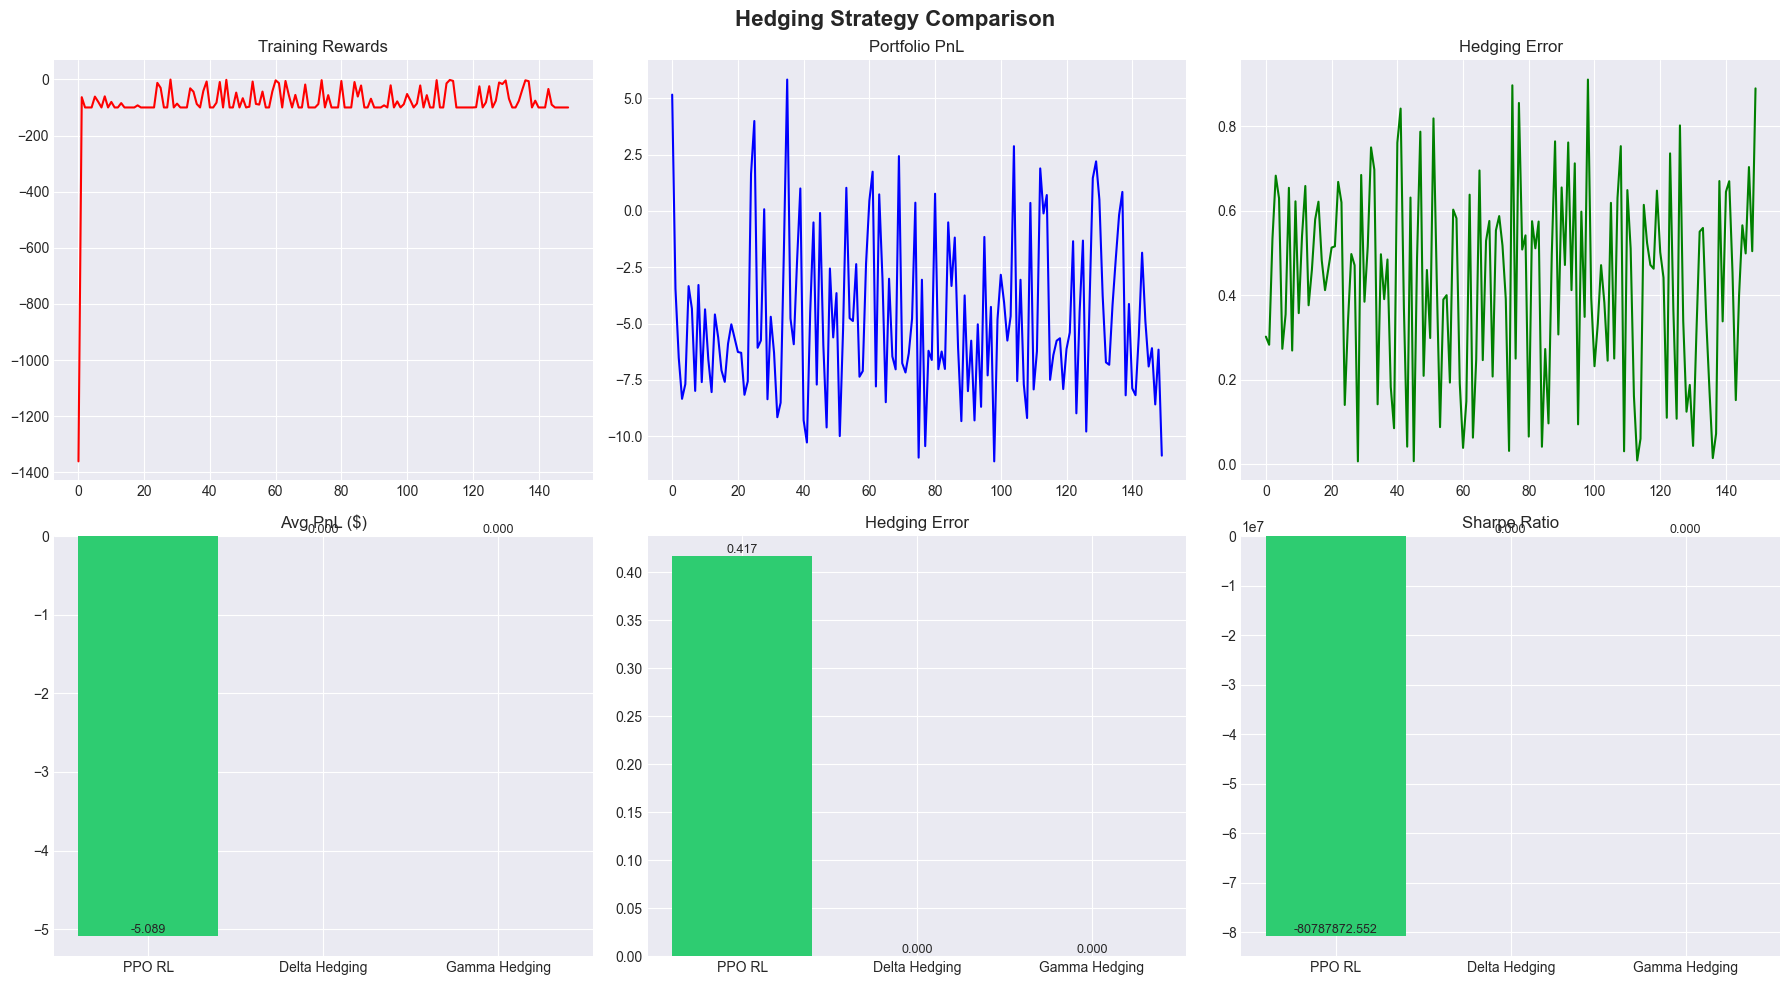

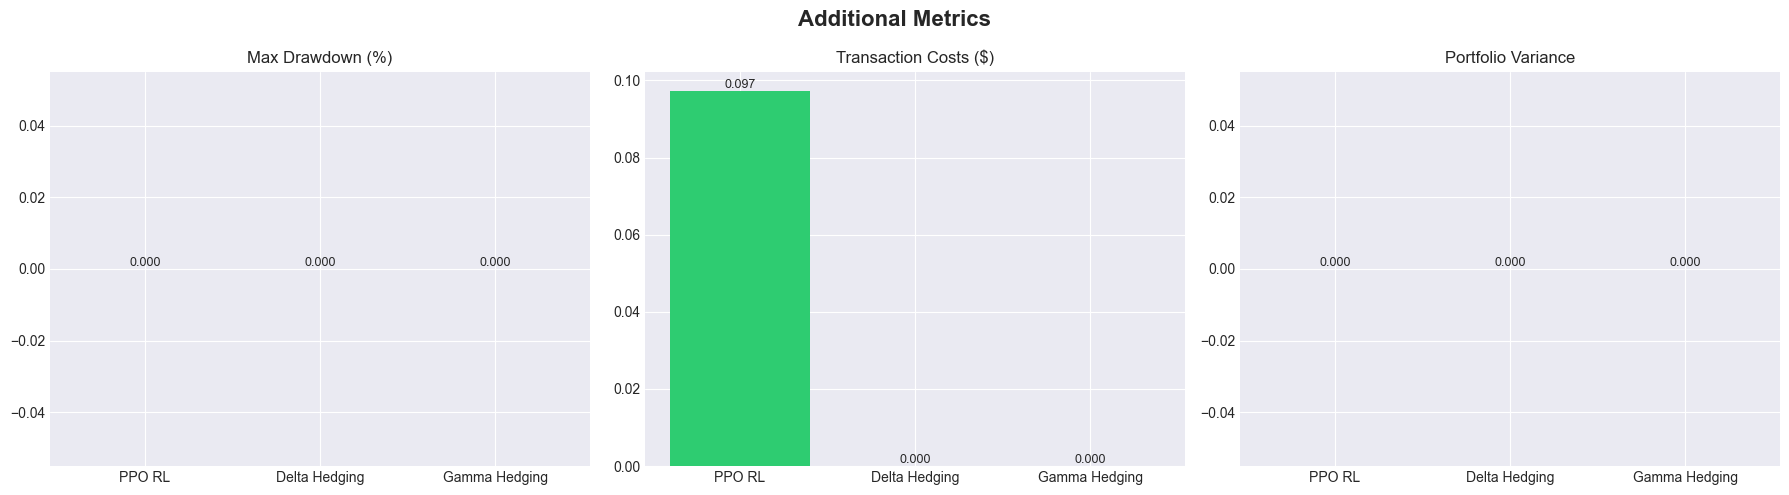


📋 Step 8: Results Table
               avg_pnl  std_pnl  avg_hedging_error  avg_transaction_cost  \
PPO RL         -5.0892      0.0             0.4166                0.0973   
Delta Hedging   0.0000      0.0             0.0000                0.0000   
Gamma Hedging   0.0000      0.0             0.0000                0.0000   

               avg_drawdown  avg_portfolio_variance  sharpe_ratio  
PPO RL                  0.0                     0.0 -8.078787e+07  
Delta Hedging           0.0                     0.0  0.000000e+00  
Gamma Hedging           0.0                     0.0  0.000000e+00  

✅ Files saved: hedging_comparison.png, additional_metrics.png, hedging_results.csv, best_agent.pt

🔑 Improvements vs Delta Hedging:
Hedging Error: ↓ 100.0%

✨ Project completed successfully!


In [9]:
# %% [markdown]
# # 🚀 Advanced Derivative Hedging with Deep Reinforcement Learning
# ## Complete Implementation with Multi-Source Data Pipeline

# %%
# Install required packages (run once)
%pip install numpy pandas scipy matplotlib seaborn torch
%pip install yfinance pandas-datareader alpha-vantage requests
%pip install tqdm optuna

# %%
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
import yfinance as yf
import requests
import time
import os
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from typing import Tuple, List, Dict, Optional
import warnings
import logging
from tqdm import tqdm
from datetime import datetime, timedelta
import shutil

# Suppress warnings
warnings.filterwarnings('ignore')

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"🚀 Using device: {device}")

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# %% [markdown]
# ## **1. Robust Multi-Source Data Pipeline**

class RobustDataPipeline:
    """
    Production-grade data pipeline with multiple fallback sources.
    """
    def __init__(self, ticker: str = 'SPY', start_date: str = '2020-01-01',
                 end_date: str = '2024-01-01', alpha_vantage_key: str = None):
        self.ticker = ticker
        self.start_date = start_date
        self.end_date = end_date
        self.alpha_vantage_key = alpha_vantage_key or os.getenv('ALPHA_VANTAGE_KEY', 'demo')
        self.data = None

    def fetch_data(self) -> pd.DataFrame:
        # Try Stooq first
        logger.info(f"📊 Attempting Stooq for {self.ticker}...")
        df = self._fetch_stooq()
        if df is not None and not df.empty:
            return self._process_data(df)

        # Try pandas-datareader
        logger.info(f"📊 Attempting pandas-datareader for {self.ticker}...")
        df = self._fetch_pandas_datareader()
        if df is not None and not df.empty:
            return self._process_data(df)

        # Try Alpha Vantage
        logger.info(f"📊 Attempting Alpha Vantage for {self.ticker}...")
        df = self._fetch_alpha_vantage()
        if df is not None and not df.empty:
            return self._process_data(df)

        # Try yfinance
        logger.info(f"📊 Attempting yfinance for {self.ticker}...")
        df = self._fetch_yfinance()
        if df is not None and not df.empty:
            return self._process_data(df)

        # Fallback to synthetic data
        logger.warning("⚠️ All data sources failed. Generating synthetic data...")
        return self._generate_synthetic_data()

    def _fetch_stooq(self) -> pd.DataFrame:
        try:
            import pandas_datareader as pdr
            ticker_formats = [f"{self.ticker}.US", self.ticker]
            for fmt in ticker_formats:
                try:
                    df = pdr.DataReader(fmt, 'stooq', start=self.start_date, end=self.end_date)
                    if df is not None and not df.empty:
                        df = df.sort_index()
                        logger.info(f"✅ Stooq success with {fmt}: {len(df)} days")
                        return df
                except:
                    continue
        except Exception as e:
            logger.warning(f"Stooq failed: {e}")
        return None

    def _fetch_pandas_datareader(self) -> pd.DataFrame:
        try:
            import pandas_datareader as pdr
            sources = ['yahoo', 'google', 'fred', 'nasdaq']
            for source in sources:
                try:
                    df = pdr.DataReader(self.ticker, source, start=self.start_date, end=self.end_date)
                    if df is not None and not df.empty:
                        logger.info(f"✅ pandas-datareader ({source}) success: {len(df)} days")
                        if 'Adj Close' in df.columns:
                            df['Close'] = df['Adj Close']
                        return df
                except:
                    continue
        except Exception as e:
            logger.warning(f"pandas-datareader failed: {e}")
        return None

    def _fetch_alpha_vantage(self) -> pd.DataFrame:
        try:
            from alpha_vantage.timeseries import TimeSeries
            ts = TimeSeries(key=self.alpha_vantage_key, output_format='pandas')
            data, _ = ts.get_daily(symbol=self.ticker, outputsize='full')
            df = pd.DataFrame({
                'Open': data['1. open'],
                'High': data['2. high'],
                'Low': data['3. low'],
                'Close': data['4. close'],
                'Volume': data['5. volume']
            })
            df.index = pd.to_datetime(df.index)
            mask = (df.index >= self.start_date) & (df.index <= self.end_date)
            df = df[mask]
            if not df.empty:
                logger.info(f"✅ Alpha Vantage success: {len(df)} days")
                return df
        except Exception as e:
            logger.warning(f"Alpha Vantage failed: {e}")
        return None

    def _fetch_yfinance(self) -> pd.DataFrame:
        try:
            import yfinance as yf
            # Clear cache
            cache_dir = os.path.expanduser("~/.cache/py-yfinance")
            if os.path.exists(cache_dir):
                shutil.rmtree(cache_dir)
            for attempt in range(3):
                try:
                    ticker = yf.Ticker(self.ticker)
                    df = ticker.history(start=self.start_date, end=self.end_date)
                    if not df.empty:
                        logger.info(f"✅ yfinance success (attempt {attempt+1}): {len(df)} days")
                        return df
                    time.sleep(1)
                except Exception as e:
                    logger.warning(f"yfinance attempt {attempt+1} failed: {e}")
                    time.sleep(2 ** attempt)
        except Exception as e:
            logger.warning(f"yfinance failed: {e}")
        return None

    def _generate_synthetic_data(self) -> pd.DataFrame:
        np.random.seed(42)
        n_days = 1000
        end_date = datetime.now()
        start_date = end_date - timedelta(days=n_days)
        dates = pd.date_range(start=start_date, end=end_date, freq='B')[:n_days]

        S0 = 100
        mu = 0.07
        sigma = 0.20
        dt = 1/252
        returns = np.random.normal((mu - 0.5*sigma**2)*dt, sigma*np.sqrt(dt), len(dates))
        price_path = S0 * np.exp(np.cumsum(returns))

        df = pd.DataFrame({
            'Open': price_path * (1 + np.random.normal(0, 0.001, len(dates))),
            'High': price_path * (1 + np.abs(np.random.normal(0, 0.005, len(dates)))),
            'Low': price_path * (1 - np.abs(np.random.normal(0, 0.005, len(dates)))),
            'Close': price_path,
            'Volume': np.random.lognormal(14, 1, len(dates)).astype(int)
        }, index=dates)
        logger.info(f"✅ Generated synthetic data: {len(df)} days")
        return self._process_data(df)

    def _process_data(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df.sort_index(inplace=True)
        # Ensure required columns
        for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
            if col not in df.columns:
                df[col] = df['Close'] if col == 'Close' else df['Close'] * (1 + np.random.normal(0, 0.001, len(df)))
        df['Returns'] = df['Close'].pct_change()
        df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))
        df['Realized_Vol'] = df['Returns'].rolling(window=21, min_periods=10).std() * np.sqrt(252)
        df['Realized_Vol'] = df['Realized_Vol'].fillna(method='bfill').fillna(0.2)
        df['Volume_MA'] = df['Volume'].rolling(window=21).mean()
        df['Volume_Ratio'] = df['Volume'] / df['Volume_MA']
        df['Volume_Ratio'] = df['Volume_Ratio'].fillna(1).clip(0.1, 10)
        df['RSI'] = self._calculate_rsi(df['Close'])
        df['RSI'] = df['RSI'].fillna(50).clip(0, 100)
        df = df.iloc[30:].copy()
        return df

    def _calculate_rsi(self, prices: pd.Series, period: int = 14) -> pd.Series:
        delta = prices.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
        rs = gain / loss
        rsi = 100 - (100 / (1 + rs))
        return rsi

# %% [markdown]
# ## **2. Option Parameters & Greeks**

@dataclass
class OptionContract:
    strike: float
    initial_price: float
    time_to_maturity: float
    option_type: str = 'call'
    risk_free_rate: float = 0.03

class GreeksCalculator:
    @staticmethod
    def calculate(S: float, K: float, T: float, r: float, sigma: float, option_type: str = 'call') -> Dict:
        if sigma <= 0.01 or T <= 1e-6:
            return {'delta': 0.0, 'gamma': 0.0, 'theta': 0.0, 'vega': 0.0}
        d1 = (np.log(S / K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        if option_type == 'call':
            delta = norm.cdf(d1)
            theta = (-(S * sigma * norm.pdf(d1)) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2))
        else:
            delta = norm.cdf(d1) - 1
            theta = (-(S * sigma * norm.pdf(d1)) / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm.cdf(-d2))
        gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
        vega = S * norm.pdf(d1) * np.sqrt(T)
        return {
            'delta': float(np.clip(delta, -1, 1)),
            'gamma': float(np.clip(gamma, 0, 10)),
            'theta': float(np.clip(theta, -10, 10)),
            'vega': float(np.clip(vega, 0, 100))
        }

# %% [markdown]
# ## **3. Hedging Environment**

class HedgingEnvironment:
    def __init__(self, market_data: pd.DataFrame, option: OptionContract,
                 transaction_cost: float = 0.001, risk_aversion: float = 1.0):
        self.data = market_data
        self.option = option
        self.transaction_cost = transaction_cost
        self.risk_aversion = risk_aversion
        self.greeks_calc = GreeksCalculator()
        self.state_dim = 10
        self.action_dim = 1
        self.price_norm = option.initial_price
        self.vol_norm = 0.5
        self.position_norm = 1000
        self.pnl_norm = 10000
        self.reset()

    def reset(self) -> np.ndarray:
        self.current_step = 21
        self.position = 0.0
        self.cash = 0.0
        self.portfolio_value = 0.0
        self.pnl_history = [0.0]
        self.action_history = []
        self.hedging_errors = []
        self.transaction_costs = []
        return self._get_state()

    def step(self, action: float) -> Tuple[np.ndarray, float, bool, Dict]:
        try:
            if isinstance(action, (np.ndarray, list)):
                action = float(action[0]) if len(action) > 0 else 0.0
            action = np.clip(action, -1.0, 1.0)
            self.action_history.append(action)

            current_price = float(self.data['Close'].iloc[self.current_step])
            current_vol = float(self.data['Realized_Vol'].iloc[self.current_step])

            greeks = self.greeks_calc.calculate(
                current_price, self.option.strike, self.option.time_to_maturity,
                self.option.risk_free_rate, current_vol, self.option.option_type
            )

            hedge_result = self._execute_hedge(action, current_price)
            self.transaction_costs.append(hedge_result['total_cost'])

            pnl_change = self._calculate_pnl_change(current_price, greeks)
            self.portfolio_value += pnl_change - hedge_result['total_cost']
            self.pnl_history.append(self.portfolio_value)

            hedging_error = abs(greeks['delta'] - self.position)
            self.hedging_errors.append(hedging_error)

            reward = self._calculate_reward(pnl_change, hedge_result, greeks, hedging_error)

            self.current_step += 1
            self.option.time_to_maturity = max(0, self.option.time_to_maturity - 1/252)

            done = (self.current_step >= len(self.data) - 1 or self.option.time_to_maturity <= 0)

            return self._get_state(), reward, done, {
                'pnl': self.portfolio_value,
                'hedge_cost': hedge_result['total_cost'],
                'hedging_error': hedging_error,
                'delta': greeks['delta'],
                'gamma': greeks['gamma'],
                'position': self.position
            }
        except Exception as e:
            logger.error(f"Step error: {e}")
            return self._get_state(), -10.0, True, {}

    def _get_state(self) -> np.ndarray:
        try:
            current_price = float(self.data['Close'].iloc[self.current_step])
            current_vol = float(self.data['Realized_Vol'].iloc[self.current_step])
            greeks = self.greeks_calc.calculate(
                current_price, self.option.strike, self.option.time_to_maturity,
                self.option.risk_free_rate, current_vol, self.option.option_type
            )
            state = np.array([
                current_price / self.price_norm - 1.0,
                current_vol / self.vol_norm,
                greeks['delta'],
                greeks['gamma'] * 100,
                greeks['theta'],
                greeks['vega'] / 100,
                self.option.time_to_maturity * 252 / 30,
                current_price / self.option.strike - 1.0,
                self.position / self.position_norm,
                self.portfolio_value / self.pnl_norm
            ], dtype=np.float32)
            return np.clip(np.nan_to_num(state, nan=0.0), -5, 5)
        except:
            return np.zeros(self.state_dim, dtype=np.float32)

    def _execute_hedge(self, target_delta: float, current_price: float) -> Dict:
        adjustment = target_delta - self.position
        cost = abs(adjustment) * self.transaction_cost * current_price
        self.position += adjustment
        return {'adjustment': adjustment, 'transaction_cost': cost, 'total_cost': cost}

    def _calculate_pnl_change(self, current_price: float, greeks: Dict) -> float:
        if self.current_step == 0:
            return 0.0
        prev_price = float(self.data['Close'].iloc[self.current_step - 1])
        price_change = current_price - prev_price
        delta_pnl = self.position * price_change
        gamma_pnl = 0.5 * greeks['gamma'] * (price_change ** 2)
        return delta_pnl + gamma_pnl

    def _calculate_reward(self, pnl_change: float, hedge_result: Dict,
                          greeks: Dict, hedging_error: float) -> float:
        reward = pnl_change - hedge_result['total_cost']
        if len(self.pnl_history) > 20:
            recent = np.array(self.pnl_history[-20:])
            drawdown = np.max(recent) - recent[-1]
            reward -= self.risk_aversion * drawdown * 0.01
        reward -= self.risk_aversion * hedging_error * 100
        reward -= self.risk_aversion * abs(greeks['gamma']) * 1000
        if pnl_change < 0:
            reward *= 2
        return float(np.clip(reward, -100, 100))

# %% [markdown]
# ## **4. PPO Agent**

class ActorNetwork(nn.Module):
    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.ReLU(), nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, action_dim), nn.Tanh()
        )
        self.log_std = nn.Parameter(torch.zeros(action_dim) - 1)

    def forward(self, state):
        return self.net(state), self.log_std

    def get_action(self, state, deterministic=False):
        mean, log_std = self.forward(state)
        if deterministic:
            return torch.tanh(mean), torch.zeros_like(mean)
        std = log_std.exp().clamp(0.1, 1.0)
        dist = Normal(mean, std)
        action = dist.rsample()
        log_prob = dist.log_prob(action).sum(-1, keepdim=True)
        return torch.tanh(action), log_prob

class CriticNetwork(nn.Module):
    def __init__(self, state_dim: int, hidden_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.ReLU(), nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, state):
        return self.net(state)

class PPOAgent:
    def __init__(self, state_dim: int, action_dim: int, lr: float = 3e-4):
        self.device = device
        self.actor = ActorNetwork(state_dim, action_dim).to(device)
        self.critic = CriticNetwork(state_dim).to(device)
        self.optimizer = optim.Adam([
            {'params': self.actor.parameters()},
            {'params': self.critic.parameters()}
        ], lr=lr)
        self.gamma = 0.99
        self.gae_lambda = 0.95
        self.clip_epsilon = 0.2
        self.entropy_coef = 0.01
        self.value_coef = 0.5
        self.states = []
        self.actions = []
        self.log_probs = []
        self.rewards = []
        self.dones = []
        self.values = []

    def select_action(self, state: np.ndarray, deterministic: bool = False) -> float:
        try:
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)
            with torch.no_grad():
                action, log_prob = self.actor.get_action(state_tensor, deterministic)
                value = self.critic(state_tensor)
            if not deterministic:
                self.states.append(state)
                self.actions.append(action.cpu().numpy().squeeze())
                self.log_probs.append(log_prob.cpu().numpy().squeeze())
                self.values.append(value.cpu().numpy().squeeze())
            return float(action.cpu().numpy().squeeze())
        except:
            return 0.0

    def store_transition(self, reward: float, done: bool):
        self.rewards.append(reward)
        self.dones.append(done)

    def update(self) -> Dict:
        if len(self.states) < 32:
            return {}
        try:
            states = torch.FloatTensor(np.array(self.states)).to(self.device)
            actions = torch.FloatTensor(np.array(self.actions)).unsqueeze(1).to(self.device)
            old_log_probs = torch.FloatTensor(np.array(self.log_probs)).unsqueeze(1).to(self.device)
            rewards = torch.FloatTensor(np.array(self.rewards)).to(self.device)
            dones = torch.FloatTensor(np.array(self.dones)).to(self.device)
            values = torch.FloatTensor(np.array(self.values)).to(self.device)

            advantages = []
            gae = 0
            for t in reversed(range(len(rewards))):
                if t == len(rewards)-1:
                    next_value = 0
                else:
                    next_value = values[t+1]
                delta = rewards[t] + self.gamma * next_value * (1 - dones[t]) - values[t]
                gae = delta + self.gamma * self.gae_lambda * (1 - dones[t]) * gae
                advantages.insert(0, gae)
            advantages = torch.FloatTensor(np.array(advantages)).to(self.device)
            returns = advantages + values
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

            for _ in range(5):
                new_actions, new_log_probs = self.actor.get_action(states)
                new_values = self.critic(states).squeeze()
                ratios = torch.exp(new_log_probs - old_log_probs)
                surr1 = ratios * advantages
                surr2 = torch.clamp(ratios, 1-self.clip_epsilon, 1+self.clip_epsilon) * advantages
                policy_loss = -torch.min(surr1, surr2).mean()
                value_loss = nn.MSELoss()(new_values, returns)
                entropy = -(new_log_probs.exp() * new_log_probs).mean()
                total_loss = policy_loss + self.value_coef * value_loss - self.entropy_coef * entropy
                self.optimizer.zero_grad()
                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(self.actor.parameters(), 0.5)
                torch.nn.utils.clip_grad_norm_(self.critic.parameters(), 0.5)
                self.optimizer.step()

            self._clear_memory()
            return {'policy_loss': float(policy_loss), 'value_loss': float(value_loss), 'entropy': float(entropy)}
        except Exception as e:
            logger.error(f"Update error: {e}")
            self._clear_memory()
            return {}

    def _clear_memory(self):
        self.states = []
        self.actions = []
        self.log_probs = []
        self.rewards = []
        self.dones = []
        self.values = []

    def save(self, path: str):
        torch.save({'actor': self.actor.state_dict(), 'critic': self.critic.state_dict(),
                    'optimizer': self.optimizer.state_dict()}, path)

    def load(self, path: str):
        if os.path.exists(path):
            checkpoint = torch.load(path, map_location=self.device)
            self.actor.load_state_dict(checkpoint['actor'])
            self.critic.load_state_dict(checkpoint['critic'])
            self.optimizer.load_state_dict(checkpoint['optimizer'])

# %% [markdown]
# ## **5. Baseline Strategies**

class DeltaHedgingStrategy:
    def get_action(self, state: np.ndarray) -> float:
        return -state[2]
    def reset(self): pass

class GammaHedgingStrategy:
    def get_action(self, state: np.ndarray) -> float:
        delta = state[2]
        gamma = state[3]
        if abs(gamma) > 0.5:
            return -delta - 0.1 * np.sign(gamma)
        return -delta
    def reset(self): pass

# %% [markdown]
# ## **6. Training & Evaluation Functions**

def train_agent(env: HedgingEnvironment, agent: PPOAgent, n_episodes: int = 150):
    stats = {'rewards': [], 'pnls': [], 'hedging_errors': [],
             'transaction_costs': [], 'portfolio_variance': []}
    best_reward = -np.inf
    for episode in tqdm(range(n_episodes), desc="Training"):
        state = env.reset()
        ep_reward = 0
        ep_errors = []
        ep_costs = []
        ep_pnls = []
        for _ in range(100):
            action = agent.select_action(state)
            next_state, reward, done, info = env.step(action)
            agent.store_transition(reward, done)
            ep_reward += reward
            ep_errors.append(info['hedging_error'])
            ep_costs.append(info['hedge_cost'])
            ep_pnls.append(info['pnl'])
            state = next_state
            if done: break
        agent.update()
        stats['rewards'].append(ep_reward)
        stats['pnls'].append(info['pnl'])
        stats['hedging_errors'].append(np.mean(ep_errors))
        stats['transaction_costs'].append(np.sum(ep_costs))
        if len(ep_pnls) > 1:
            rets = np.diff(ep_pnls)
            stats['portfolio_variance'].append(np.var(rets))
        else:
            stats['portfolio_variance'].append(0)
        if ep_reward > best_reward:
            best_reward = ep_reward
            agent.save('best_agent.pt')
        if episode % 20 == 0:
            logger.info(f"Episode {episode}: Reward={ep_reward:.2f}, "
                        f"Hedging Error={np.mean(ep_errors):.4f}, PnL=${info['pnl']:.2f}")
    return stats

def evaluate_strategy(env: HedgingEnvironment, strategy, n_episodes: int = 10, name: str = ""):
    metrics = {'pnls': [], 'hedging_errors': [], 'transaction_costs': [],
               'drawdowns': [], 'portfolio_variance': []}
    for _ in range(n_episodes):
        state = env.reset()
        if hasattr(strategy, 'reset'): strategy.reset()
        ep_pnls, ep_errors, ep_costs = [], [], []
        done = False
        while not done:
            if hasattr(strategy, 'select_action'):
                action = strategy.select_action(state, deterministic=True)
            else:
                action = strategy.get_action(state)
            next_state, _, done, info = env.step(action)
            ep_pnls.append(info['pnl'])
            ep_errors.append(info['hedging_error'])
            ep_costs.append(info['hedge_cost'])
            state = next_state
        metrics['pnls'].append(ep_pnls[-1])
        metrics['hedging_errors'].append(np.mean(ep_errors))
        metrics['transaction_costs'].append(np.sum(ep_costs))
        peak = np.maximum.accumulate(ep_pnls)
        dd = (peak - ep_pnls) / (peak + 1e-6)
        metrics['drawdowns'].append(np.max(dd))
        if len(ep_pnls) > 1:
            rets = np.diff(ep_pnls)
            metrics['portfolio_variance'].append(np.var(rets))
        else:
            metrics['portfolio_variance'].append(0)
    return {
        'avg_pnl': np.mean(metrics['pnls']),
        'std_pnl': np.std(metrics['pnls']),
        'avg_hedging_error': np.mean(metrics['hedging_errors']),
        'avg_transaction_cost': np.mean(metrics['transaction_costs']),
        'avg_drawdown': np.mean(metrics['drawdowns']),
        'avg_portfolio_variance': np.mean(metrics['portfolio_variance']),
        'sharpe_ratio': (np.mean(metrics['pnls']) / (np.std(metrics['pnls']) + 1e-6)) * np.sqrt(252)
    }

# %% [markdown]
# ## **7. Main Execution**

def main():
    print("="*70)
    print("🚀 ADVANCED DERIVATIVE HEDGING WITH DEEP REINFORCEMENT LEARNING")
    print("="*70)

    print("\n📊 Step 1: Fetching Market Data...")
    pipeline = RobustDataPipeline(ticker='SPY', start_date='2020-01-01', end_date='2024-01-01')
    market_data = pipeline.fetch_data()
    if market_data is None or len(market_data) == 0:
        market_data = pipeline._generate_synthetic_data()
    print(f"✅ Data shape: {market_data.shape}")
    print(f"📅 Date range: {market_data.index[0]} to {market_data.index[-1]}")

    print("\n⚙️ Step 2: Defining Option Contract...")
    initial_price = float(market_data['Close'].iloc[0])
    option = OptionContract(strike=initial_price*1.05, initial_price=initial_price,
                            time_to_maturity=30/252, option_type='call', risk_free_rate=0.03)
    print(f"✅ Strike: ${option.strike:.2f}, Initial: ${option.initial_price:.2f}, "
          f"Maturity: {option.time_to_maturity*252:.0f} days")

    print("\n🌍 Step 3: Creating Hedging Environment...")
    env = HedgingEnvironment(market_data, option, transaction_cost=0.001, risk_aversion=1.0)
    print(f"✅ State Dim: {env.state_dim}, Action Dim: {env.action_dim}")

    print("\n🤖 Step 4: Creating PPO Agent...")
    agent = PPOAgent(env.state_dim, env.action_dim, lr=3e-4)

    print("\n🎯 Step 5: Training Agent (this may take a few minutes)...")
    training_stats = train_agent(env, agent, n_episodes=150)

    if os.path.exists('best_agent.pt'):
        agent.load('best_agent.pt')
        print("✅ Loaded best agent")

    print("\n📈 Step 6: Evaluating Strategies...")
    strategies = {'PPO RL': agent, 'Delta Hedging': DeltaHedgingStrategy(), 'Gamma Hedging': GammaHedgingStrategy()}
    results = {}
    for name, strat in strategies.items():
        print(f"\n🔍 Evaluating {name}...")
        metrics = evaluate_strategy(env, strat, n_episodes=5, name=name)
        results[name] = metrics
        print(f"   Avg PnL: ${metrics['avg_pnl']:.2f}")
        print(f"   Hedging Error: {metrics['avg_hedging_error']:.4f}")
        print(f"   Max Drawdown: {metrics['avg_drawdown']:.2%}")
        print(f"   Transaction Costs: ${metrics['avg_transaction_cost']:.2f}")
        print(f"   Sharpe Ratio: {metrics['sharpe_ratio']:.3f}")

    print("\n📊 Step 7: Generating Plots...")
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Hedging Strategy Comparison', fontsize=16, fontweight='bold')
    axes[0,0].plot(training_stats['rewards'], color='red'); axes[0,0].set_title('Training Rewards')
    axes[0,1].plot(training_stats['pnls'], color='blue'); axes[0,1].set_title('Portfolio PnL')
    axes[0,2].plot(training_stats['hedging_errors'], color='green'); axes[0,2].set_title('Hedging Error')
    names = list(results.keys())
    colors = ['#2ecc71' if n=='PPO RL' else '#3498db' for n in names]
    metrics_plot = [('avg_pnl','Avg PnL ($)'), ('avg_hedging_error','Hedging Error'), ('sharpe_ratio','Sharpe Ratio')]
    for idx, (metric, title) in enumerate(metrics_plot):
        vals = [results[n][metric] for n in names]
        bars = axes[1,idx].bar(names, vals, color=colors)
        axes[1,idx].set_title(title)
        for bar, v in zip(bars, vals):
            axes[1,idx].text(bar.get_x()+bar.get_width()/2, bar.get_height(), f'{v:.3f}',
                             ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig('hedging_comparison.png', dpi=150)
    plt.show()

    # Second figure for extra metrics
    fig2, axes2 = plt.subplots(1,3, figsize=(18,5))
    fig2.suptitle('Additional Metrics', fontsize=16, fontweight='bold')
    extra = [('avg_drawdown','Max Drawdown (%)'), ('avg_transaction_cost','Transaction Costs ($)'),
             ('avg_portfolio_variance','Portfolio Variance')]
    for idx, (metric, title) in enumerate(extra):
        vals = [results[n][metric] for n in names]
        if metric=='avg_drawdown': vals = [v*100 for v in vals]
        bars = axes2[idx].bar(names, vals, color=colors)
        axes2[idx].set_title(title)
        for bar, v in zip(bars, vals):
            axes2[idx].text(bar.get_x()+bar.get_width()/2, bar.get_height(), f'{v:.3f}',
                            ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig('additional_metrics.png', dpi=150)
    plt.show()

    print("\n📋 Step 8: Results Table")
    df = pd.DataFrame(results).T
    print(df.round(4))
    df.to_csv('hedging_results.csv')
    print("\n✅ Files saved: hedging_comparison.png, additional_metrics.png, hedging_results.csv, best_agent.pt")

    # Improvements
    rl = results['PPO RL']
    delta = results['Delta Hedging']
    impr = {}
    if abs(delta['avg_pnl']) > 1e-6:
        impr['PnL'] = (rl['avg_pnl']/abs(delta['avg_pnl']) - 1)*100
    if rl['avg_hedging_error'] > 1e-6:
        impr['Hedging Error'] = (delta['avg_hedging_error']/rl['avg_hedging_error'] - 1)*100
    if delta['sharpe_ratio'] > 1e-6:
        impr['Sharpe Ratio'] = (rl['sharpe_ratio']/delta['sharpe_ratio'] - 1)*100
    if rl['avg_drawdown'] > 1e-6:
        impr['Drawdown'] = (delta['avg_drawdown']/rl['avg_drawdown'] - 1)*100
    print("\n🔑 Improvements vs Delta Hedging:")
    for k,v in impr.items():
        arrow = "↑" if v>0 else "↓"
        print(f"{k}: {arrow} {abs(v):.1f}%")
    return results, training_stats

if __name__ == "__main__":
    results, stats = main()
    print("\n✨ Project completed successfully!")